# AppleSupport Customer-Support Agent

Intent classification, AUTO/ESCALATE routing, retrieval of historical brand replies, and grounded response generation, evaluated on a 200-example human-labelled Golden Set.

## 1. Setup and data

**Notebook organization note:** Cells are arranged as a narrative pipeline. Existing experiments and results have been preserved; expensive Gemini generation and judge calls are controlled by the existing safety switches and saved-progress files.

## Problem Framing

### What "good" means for AppleSupport

For this project, a good customer-support agent should:

- Correctly identify the customer's support intent.
- Use historical AppleSupport responses as grounding rather than inventing unsupported information.
- Produce a concise, professional, and natural response.
- Provide useful next steps when the historical response supports them.
- Avoid unsupported claims, guarantees, policies, or troubleshooting instructions.
- Escalate cases that are ambiguous, sensitive, or outside the predefined auto-handling policy.

The system therefore prioritizes **groundedness, relevance, helpfulness, and safe handling** rather than optimizing for response generation alone.

### What we chose not to build

We deliberately kept the scope limited to a research prototype rather than a production customer-support system. We did not build:

- A fully autonomous support agent that can perform account/device actions.
- Integration with Apple's internal support systems or customer accounts.
- A production-grade multi-turn conversation manager.
- A complete policy/safety system for every possible AppleSupport scenario.
- Reinforcement learning or online learning from live customer interactions.

The goal was to evaluate whether a lightweight intent-classification, retrieval, and grounded-generation pipeline could provide useful and appropriately handled customer-support responses on historical Twitter data.

## 2. Environment and Setup

The following cells install dependencies, import libraries, configure Gemini, and prepare the notebook runtime.

In [ ]:
from google.colab import userdata
from google import genai

In [116]:
# ============================================================
# GEMINI CONFIGURATION
# ============================================================

USE_GEMINI = False
USE_GEMINI_JUDGE = True

GEMINI_MODEL = "gemini-3.6-flash"

GENERATION_DELAY = 10

print("Gemini enabled:", USE_GEMINI)
print("Gemini judge enabled:", USE_GEMINI_JUDGE)
print("Gemini model:", GEMINI_MODEL)
print("Generation delay:", GENERATION_DELAY, "seconds")

Gemini enabled: False
Gemini judge enabled: True
Gemini model: gemini-3.6-flash
Generation delay: 10 seconds


In [ ]:
# Install required libraries
!pip -q install kagglehub pandas numpy scikit-learn matplotlib seaborn tqdm
!pip -q install sentence-transformers transformers sentencepiece accelerate
!pip -q install -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.4/262.4 kB 21.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.0 which is incompatible.


In [ ]:
import os
import re
import json
import time
import numpy as np
import pandas as pd

from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_colwidth", 300)

print("Environment ready!")

Environment ready!


## 3. Dataset and Brand Selection

We use the Customer Support on Twitter dataset and focus the prototype on AppleSupport. Customer tweets are paired with the corresponding AppleSupport replies using the dataset's tweet IDs.

In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "thoughtvector/customer-support-on-twitter"
)

print("Dataset downloaded to:")
print(dataset_path)

Using Colab cache for faster access to the 'customer-support-on-twitter' dataset.
Dataset downloaded to:
/kaggle/input/customer-support-on-twitter


In [ ]:
import pandas as pd

csv_path = os.path.join(dataset_path, "twcs", "twcs.csv")

df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (2811774, 7)

Columns:
['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messages and no one is responding as usual,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so that we can further assist you. Just click ‘Message’ at the top of your profile.,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [ ]:
# Brand accounts are the tweets where inbound == False
brand_tweets = df[df["inbound"] == False]

print("Number of brand tweets:", len(brand_tweets))

# Count tweets by brand account
brand_counts = brand_tweets["author_id"].value_counts()

print("\nTop 30 brands/accounts:")
print(brand_counts.head(30))

Number of brand tweets: 1273931

Top 30 brands/accounts:
author_id
AmazonHelp         169840
AppleSupport       106860
Uber_Support        56270
SpotifyCares        43265
Delta               42253
Tesco               38573
AmericanAir         36764
TMobileHelp         34317
comcastcares        33031
British_Airways     29361
SouthwestAir        28977
VirginTrains        27817
Ask_Spectrum        25860
XboxSupport         24557
sprintcare          22381
hulu_support        21872
sainsburys          19466
GWRHelp             19364
AskPlayStation      19098
ChipotleTweets      18749
VerizonSupport      17966
UPSHelp             17817
ATVIAssist          17650
O2                  16212
Safaricom_Care      16077
idea_cares          15724
AskTarget           13218
AirAsiaSupport      12829
BofA_Help           12683
SW_Help             12231
Name: count, dtype: int64


In [ ]:
BRAND = "AppleSupport"

# AppleSupport's outgoing replies
apple_replies = df[
    (df["author_id"] == BRAND) &
    (df["inbound"] == False)
].copy()

# IDs of customer tweets that Apple directly replied to
customer_ids = apple_replies["in_response_to_tweet_id"].dropna()

# Customer messages
apple_customers = df[
    df["tweet_id"].isin(customer_ids)
].copy()

print("Apple customer messages:", len(apple_customers))
print("Apple brand replies:", len(apple_replies))

Apple customer messages: 106625
Apple brand replies: 106860


In [ ]:
apple_pairs = apple_customers.merge(
    apple_replies[
        ["tweet_id", "text", "created_at", "in_response_to_tweet_id"]
    ],
    left_on="tweet_id",
    right_on="in_response_to_tweet_id",
    suffixes=("_customer", "_brand")
)

print("Customer → Apple response pairs:", len(apple_pairs))

apple_pairs[
    ["text_customer", "text_brand"]
].head(10)

Customer → Apple response pairs: 106648


,text_customer,text_brand
0,@AppleSupport The newest update. I️ made sure to download it yesterday.,@115854 Lets take a closer look into this issue. Select the following link to join us in a DM and we'll go from there. https://t.co/GDrqU22YpT
1,@AppleSupport https://t.co/NV0yucs0lB,@115854 We're here for you. Which version of the iOS are you running? Check from Settings &gt; General &gt; About.
2,@AppleSupport Tried resetting my settings .. restarting my phone .. all that,@115855 Let's go to DM for the next steps. DM us here: https://t.co/GDrqU22YpT
3,@AppleSupport This is what it looks like https://t.co/XCQU2l4xUB,@115855 Any steps tried since it started last night?
4,@AppleSupport I️ have an iPhone 7 Plus and yes I️ do,@115855 That's great it has iOS 11.1 as we can rule out being outdated. Any steps tried since this started? Do you recall when it started?
5,@AppleSupport I️ need answers because it’s annoying 🙃,@115855 We'd like to look into this with you. Which model do you have and is iOS 11.1 installed? Any steps tried so far?
6,"Hey @AppleSupport and anyone else who upgraded to ios11.1, are y’all having issues with capital “I️” in the Mail app? As it puts in “A”?","@115856 Hey, let's work together to figure out what's going on. Meet us in DM and we'll continue from there. https://t.co/GDrqU22YpT"
7,@AppleSupport This is what is happening... https://t.co/X3SZSJXfAT,@115857 We'd like to investigate further with you. Send us a DM and we can troubleshoot more from there. https://t.co/GDrqU22YpT
8,Tf is wrong with my keyboard @115858,"@115857 Fill us in on what is happening, then we can help out from there."
9,@AppleSupport are the call centres closed for the night?,@115859 We've received your DM and will continue there.


## 4. Exploratory Analysis

Word frequencies and unsupervised clustering were used only to understand what customers write about; they were not treated as ground-truth intents.

In [ ]:
# Most frequent words in a 10,000-message sample
explore = apple_pairs["text_customer"].dropna().sample(10000, random_state=42)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # URLs
    text = re.sub(r"@\w+", " ", text)              # mentions
    text = re.sub(r"[^a-z\s]", " ", text)          # keep letters only
    return [w for w in text.split() if len(w) > 2]

word_counts = Counter()
for text in explore:
    word_counts.update(clean_text(text))

for word, count in word_counts.most_common(25):
    print(f"{word:<20} {count}")

the                  5350
and                  3236
this                 2454
phone                2080
iphone               2048
ios                  2016
update               1469
can                  1366
you                  1356
fix                  1348
with                 1332
for                  1261
have                 1224
not                  1104
that                 1062
all                  916
when                 909
why                  891
but                  868
new                  857
apple                849
what                 803
battery              800
just                 782
now                  754


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Use the same 10,000 customer messages
texts = explore.tolist()

# Convert messages into TF-IDF features
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5
)

X = vectorizer.fit_transform(texts)

print("Number of messages:", X.shape[0])
print("Number of TF-IDF features:", X.shape[1])

Number of messages: 10000
Number of TF-IDF features: 3562


In [ ]:
from sklearn.cluster import KMeans

# Create 12 groups of similar customer messages
kmeans = KMeans(
    n_clusters=12,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

# Add cluster number to our messages
explore_df = pd.DataFrame({
    "text": texts,
    "cluster": clusters
})

print("Clustering complete!")
print("\nMessages per cluster:")
print(explore_df["cluster"].value_counts().sort_index())

Clustering complete!

Messages per cluster:
cluster
0      607
1      258
2      981
3       99
4      958
5      723
6      138
7      364
8      326
9     4370
10    1060
11     116
Name: count, dtype: int64


In [ ]:
# Show 3 example messages from every cluster
for cluster_id in sorted(explore_df["cluster"].unique()):
    subset = explore_df[explore_df["cluster"] == cluster_id]["text"]

    print("\n" + "=" * 80)
    print(f"CLUSTER {cluster_id}")
    print("=" * 80)

    for i, text in enumerate(subset.sample(min(3, len(subset)), random_state=42), 1):
        print(f"{i}. {text}")


CLUSTER 0
1. @AppleSupport is this a scam or really Apple? See pic below that came up on my phone https://t.co/fT7cCDTgWF
2. @116333 hi,I am Apple user since 2007. Yesterday morning I got defected screen on iPhone X from Etisalat UAE at the Dubai Mall.
3. @AppleSupport please could you help me ASAP think someone has my Apple information and is perching things from it

CLUSTER 1
1. Tell me @AppleSupport @115858 how does Siri make out Masemola to be Samola #Siri https://t.co/7iejIbffRA
2. @AppleSupport is the entire device. The lock screen also does not work properly. Bug in notification banners.
3. Why does my battery die so fast since I updated to #iOS11 @115858? I see its a huge issue w a lot of people n hasnt been resolved in updates.

CLUSTER 2
1. @AppleSupport what have you done to us with iOS 11.0.3? Issues with Bluetooth, battery draining, slow response and hangs! iPhone 5s, 6 and 7
2. @115858 Why can’t I type the letter “i” with iOS 11.1? I have to touch the predictive text opt

TF-IDF + K-Means produced semantically mixed clusters, so the intent taxonomy below was defined manually after reading a sample of customer/brand pairs.

## 5. Intent Taxonomy

In [ ]:
INTENTS = {
    "ios_update": "Problems or questions specifically related to iOS software updates",

    "device_performance": "Phone or Mac freezing, crashing, rebooting, lagging, or becoming slow",

    "battery_power": "Battery draining, charging, overheating, or power-related problems",

    "keyboard_input": "Keyboard, typing, autocorrect, symbols, or the iOS 'I' character bug",

    "connectivity": "Wi-Fi, Bluetooth, car connection, tethering, or connectivity problems",

    "app_issues": "Third-party applications crashing, freezing, or not working",

    "app_store_purchases": "App Store access, downloading/updating apps, purchases, or payment issues",

    "itunes_media": "iTunes, Apple Music, music purchases, downloads, or media library problems",

    "icloud_photos": "iCloud, Photos, photo syncing, missing/deleted photos, or storage issues",

    "account_security": "Apple ID, account access, hacking, phishing, scams, or security concerns",

    "calls_messaging": "Phone calls, SMS, caller ID, or cellular communication problems",

    "hardware_accessories": "Physical device problems, damaged hardware, headphones, AirPods, or accessories",

    "other_unclear": "Messages that are too vague, image-only, unsupported, multilingual, or otherwise unclear"
}

print("Number of intents:", len(INTENTS))

for i, (name, description) in enumerate(INTENTS.items(), 1):
    print(f"{i:2}. {name:<25} - {description}")

Number of intents: 13
 1. ios_update                - Problems or questions specifically related to iOS software updates
 2. device_performance        - Phone or Mac freezing, crashing, rebooting, lagging, or becoming slow
 3. battery_power             - Battery draining, charging, overheating, or power-related problems
 4. keyboard_input            - Keyboard, typing, autocorrect, symbols, or the iOS 'I' character bug
 5. connectivity              - Wi-Fi, Bluetooth, car connection, tethering, or connectivity problems
 6. app_issues                - Third-party applications crashing, freezing, or not working
 7. app_store_purchases       - App Store access, downloading/updating apps, purchases, or payment issues
 8. itunes_media              - iTunes, Apple Music, music purchases, downloads, or media library problems
 9. icloud_photos             - iCloud, Photos, photo syncing, missing/deleted photos, or storage issues
10. account_security          - Apple ID, account access, hacking

In [ ]:
# Create our working customer dataset

customer_data = apple_pairs[
    ["tweet_id_customer", "text_customer", "text_brand"]
].copy()

customer_data = customer_data.rename(columns={
    "tweet_id_customer": "tweet_id",
    "text_customer": "customer_text",
    "text_brand": "brand_response"
})

# Remove empty messages
customer_data = customer_data.dropna(subset=["customer_text"])

# Remove duplicate customer messages
customer_data = customer_data.drop_duplicates(subset=["tweet_id"])

print("Total customer-response examples:", len(customer_data))
customer_data.head()

Total customer-response examples: 106625


,tweet_id,customer_text,brand_response
0,697,@AppleSupport The newest update. I️ made sure to download it yesterday.,@115854 Lets take a closer look into this issue. Select the following link to join us in a DM and we'll go from there. https://t.co/GDrqU22YpT
1,698,@AppleSupport https://t.co/NV0yucs0lB,@115854 We're here for you. Which version of the iOS are you running? Check from Settings &gt; General &gt; About.
2,702,@AppleSupport Tried resetting my settings .. restarting my phone .. all that,@115855 Let's go to DM for the next steps. DM us here: https://t.co/GDrqU22YpT
3,704,@AppleSupport This is what it looks like https://t.co/XCQU2l4xUB,@115855 Any steps tried since it started last night?
4,707,@AppleSupport I️ have an iPhone 7 Plus and yes I️ do,@115855 That's great it has iOS 11.1 as we can rule out being outdated. Any steps tried since this started? Do you recall when it started?


In [ ]:
# Sample data for model development

MODEL_SAMPLE_SIZE = min(20000, len(customer_data))

model_data = customer_data.sample(
    MODEL_SAMPLE_SIZE,
    random_state=42
).reset_index(drop=True)

print("Model development dataset:", len(model_data))

Model development dataset: 20000


In [ ]:
import re
import numpy as np

def assign_intent(text):
    """
    Assign a provisional intent using transparent keyword rules.
    These labels are for model development and will be manually validated.
    """

    text = str(text).lower()

    # Remove URLs and mentions
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)

    # 1. Keyboard / autocorrect
    if any(word in text for word in [
        "question mark", "keyboard", "autocorrect",
        "letter i", "typing", "type i", "symbols"
    ]):
        return "keyboard_input"

    # 2. Battery / charging / overheating
    if any(word in text for word in [
        "battery", "charge", "charging",
        "overheating", "overheat", "won't charge"
    ]):
        return "battery_power"

    # 3. Connectivity
    if any(word in text for word in [
        "bluetooth", "wi-fi", "wifi",
        "wi fi", "tethering", "car stereo",
        "hotspot", "cellular data"
    ]):
        return "connectivity"

    # 4. Security / account
    if any(word in text for word in [
        "hacked", "hack", "phishing", "scam",
        "fraud", "security", "apple id",
        "password", "compromised"
    ]):
        return "account_security"

    # 5. iCloud / Photos
    if any(word in text for word in [
        "icloud", "photo library", "photos deleted",
        "photos disappeared", "missing photos",
        "photo", "photos"
    ]):
        return "icloud_photos"

    # 6. App Store / purchases
    if any(word in text for word in [
        "app store", "download apps",
        "purchase", "purchased", "payment",
        "charged", "can't download"
    ]):
        return "app_store_purchases"

    # 7. iTunes / Apple Music
    if any(word in text for word in [
        "itunes", "apple music", "music",
        "songs", "album", "itunes store"
    ]):
        return "itunes_media"

    # 8. Calls / messaging
    if any(word in text for word in [
        "call", "calling", "calls",
        "sms", "text message", "caller id"
    ]):
        return "calls_messaging"

    # 9. iOS update
    if any(word in text for word in [
        "ios update", "ios 11", "ios 11.",
        "updated to ios", "software update",
        "latest update", "new update"
    ]):
        return "ios_update"

    # 10. Third-party app issues
    if any(word in text for word in [
        "app crashes", "app crashing",
        "app won't open", "app not working",
        "netflix", "outlook", "pandora"
    ]):
        return "app_issues"

    # 11. Hardware / accessories
    if any(word in text for word in [
        "airpods", "headphones", "earphones",
        "screen", "broken", "damaged",
        "cable", "charger"
    ]):
        return "hardware_accessories"

    # 12. General performance
    if any(word in text for word in [
        "freezing", "freeze", "laggy",
        "slow", "crash", "crashes",
        "reboot", "restarting", "restart",
        "shuts down", "shutting down"
    ]):
        return "device_performance"

    # 13. Everything unclear
    return "other_unclear"


# Apply provisional labels
model_data["intent"] = model_data["customer_text"].apply(assign_intent)

print("Provisional labels created!")
print("\nIntent distribution:")
print(model_data["intent"].value_counts())

Provisional labels created!

Intent distribution:
intent
other_unclear           10153
battery_power            1987
ios_update               1816
keyboard_input           1213
device_performance       1088
itunes_media              738
hardware_accessories      737
connectivity              559
calls_messaging           544
icloud_photos             494
account_security          377
app_store_purchases       271
app_issues                 23
Name: count, dtype: int64


## 6. Golden Evaluation Set

Each example was read individually and labelled with an intent, an AUTO/ESCALATE decision, and a written reason. The labels are stored in one block below; the annotation was done in batches of 20.

In [ ]:
# Create a candidate pool for our Golden Set

GOLDEN_SIZE = 200

# We first create a larger pool so that we can manually choose
# representative examples from it.
golden_pool = customer_data.sample(
    1000,
    random_state=2026
).reset_index(drop=True)

print("Golden Set candidate pool:", len(golden_pool))

golden_pool[
    ["tweet_id", "customer_text", "brand_response"]
].head(10)

Golden Set candidate pool: 1000


,tweet_id,customer_text,brand_response
0,2422571,Clearly need to stop using a first-person pronoun until @115858 can get their shit together.,@695800 We'd be happy to help. Have you tried the latest update? Make sure you have a backup beforehand: https://t.co/4f8hwT5to6 DM us if that doesn't work. https://t.co/GDrqU22YpT
1,2299863,"@AppleSupport Yes, and I filed a radar","@667520 This is something we'll want to address beyond that radar filing. Please let us know in DM what country you're located in, so we can advise on your options."
2,1930614,@AppleSupport Why do I get the message that my order# “does not belong to the provided account” when I try to check my iPhone order status?,"@574492 We're glad to help in any way we can, or get you pointed in the right direction. Please DM us to proceed from here. https://t.co/GDrqU22YpT"
3,921012,@AppleSupport please fix this with the next ios 11 update https://t.co/tajxvdLag7,"@338632 Hey, we can help you get connected. First, have you tried the steps here?: https://t.co/sXbhzfS2lM Let us know the results."
4,2555259,"@AppleSupport I restored to iPhone X, latest version of iOS and everything restored, except for some of my health data from the last week. Any thoughts?",@725603 Thanks for reaching out to us. We are always happy to help. Send us a DM so we can look into this with you there. https://t.co/GDrqU22YpT
5,328554,@AppleSupport yes. It doesn’t even open completely.,@194339 We'd like to look into this further with you. Please send us a DM so we can gather some additional information. https://t.co/GDrqU22YpT
6,2000295,Currently:_ Is @AppleSupport just going to ignore the fact that ALL PHONES are experiencing this question mark issue when you put “ I️ “,@591459 We certainly want to help if you're having issues. Go ahead and reach out to us in DM and we'll be glad to help. https://t.co/GDrqU22YpT
7,2452935,@115858 why is it I can’t delete my credit card off my phone? I have a big issue with this,@702782 Thanks for reaching out. We're here to help. DM us so we can look into this further with you. https://t.co/GDrqU22YpT
8,557856,@AppleSupport Figured out the problem - it was being blocked by a content blocker. Choosing Reload without Content Blockers solved it.,@250300 We're happy to hear you were able to get to the bottom of the issue. Please feel free to reach out to us for anything. It was a pleasure working with you.
9,1886557,#iOS11 update is been a disaster for me. Never thought an #iPhone could hang and become unresponsive. I use an #iPhone6. Anyone else? @115858,@244346 We're here to help. Please DM us via the following link with the exact version of iOS 11 you are using. https://t.co/GDrqU22YpT


In [ ]:
# Create columns for human annotation

golden_set = golden_pool.copy()

golden_set["intent"] = ""
golden_set["handling"] = ""
golden_set["reason"] = ""

print("Columns ready for annotation:")
print(golden_set.columns.tolist())

Columns ready for annotation:
['tweet_id', 'customer_text', 'brand_response', 'intent', 'handling', 'reason']


In [ ]:
# Human annotations for the 200 Golden Set examples
# (annotated in batches of 20 while reading each message)

labels_0_19 = [
    ("keyboard_input", "AUTO", "Clearly refers to the problematic first-person I character."),
    ("other_unclear", "ESCALATE", "Context is insufficient; customer only says they filed a radar."),
    ("app_store_purchases", "ESCALATE", "Problem concerns an iPhone order/account and order status."),
    ("ios_update", "AUTO", "Explicitly asks for a fix in the next iOS update."),
    ("icloud_photos", "ESCALATE", "Missing health data after restoring an iPhone requires account/data investigation."),
    ("app_issues", "ESCALATE", "An application apparently won't open, but exact app/context is unclear."),
    ("keyboard_input", "AUTO", "Explicitly describes the question-mark/I keyboard issue."),
    ("app_store_purchases", "ESCALATE", "Credit-card removal/payment-account issue requires account-specific assistance."),
    ("other_unclear", "AUTO", "Customer has already solved the issue; no further support is needed."),
    ("device_performance", "AUTO", "iPhone hangs and becomes unresponsive after the update."),
    ("battery_power", "AUTO", "Explicit Apple Watch battery-drain complaint."),
    ("app_store_purchases", "ESCALATE", "Brand response indicates an App Store/update issue, but customer message itself is too vague."),
    ("account_security", "ESCALATE", "Apple ID/iCloud email authentication issue requires account-specific investigation."),
    ("other_unclear", "ESCALATE", "Upgrade-program return requirements are sales/program-specific and outside our defined support intents."),
    ("device_performance", "AUTO", "Phone repeatedly freezes, indicating performance/stability problems."),
    ("keyboard_input", "AUTO", "Explicitly refers to the capital I problem."),
    ("itunes_media", "ESCALATE", "Music library items are missing from the Music app and need investigation."),
    ("battery_power", "ESCALATE", "Battery drain is the main issue, but there is also a Wi-Fi problem; DM investigation is appropriate."),
    ("keyboard_input", "AUTO", "Explicitly refers to the missing/problematic I character."),
    ("device_performance", "AUTO", "iPhone 5S is laggy/slow on iOS 11.")
]

labels_20_39 = [
    ("device_performance", "ESCALATE", "Freezing, hanging and crashing are device-performance problems, but reverting iOS needs careful support."),
    ("battery_power", "ESCALATE", "Battery drain and overheating after an update require troubleshooting."),
    ("other_unclear", "ESCALATE", "Genius Bar appointment is a service/booking issue outside our defined intents."),
    ("device_performance", "ESCALATE", "Abnormal screen behavior during startup requires hardware/software investigation."),
    ("keyboard_input", "AUTO", "Explicitly describes the autocorrect I bug."),
    ("device_performance", "ESCALATE", "Multiple issues: loudspeaker failure, app crashes, and forced restart."),
    ("ios_update", "ESCALATE", "Complaint is specifically about problems after the iOS 11 update and conflicting support advice."),
    ("hardware_accessories", "ESCALATE", "Lightning cable/charging issue requires device or accessory troubleshooting."),
    ("hardware_accessories", "AUTO", "Customer is asking about the material used in Apple covers."),
    ("device_performance", "ESCALATE", "Customer says iOS 11 made the iPhone significantly slower; message is also non-English."),
    ("connectivity", "AUTO", "Bluetooth is switching back on unexpectedly."),
    ("account_security", "ESCALATE", "Apple ID login failure combined with multiple system/service failures requires account investigation."),
    ("account_security", "AUTO", "Customer asks whether a link is a phishing/scam attempt."),
    ("calls_messaging", "ESCALATE", "Messages have disappeared and require investigation/recovery."),
    ("other_unclear", "ESCALATE", "System storage usage is a distinct storage issue not well represented by our current taxonomy."),
    ("keyboard_input", "AUTO", "Explicitly refers to the I character problem."),
    ("keyboard_input", "AUTO", "Explicitly describes the I typing/replacement problem."),
    ("keyboard_input", "AUTO", "Explicitly asks about the I problem."),
    ("itunes_media", "AUTO", "Apple Music trial cancellation is a subscription/media-service issue."),
    ("itunes_media", "AUTO", "Customer is discussing an Apple Music/app subscription change and giving feedback.")
]

labels_40_59 = [
    ("other_unclear", "ESCALATE", "The actual issue is contained in an image/link, so the text alone is insufficient."),
    ("device_performance", "ESCALATE", "iPhone is hanging after updates and needs troubleshooting."),
    ("other_unclear", "AUTO", "This is simply thanks/positive feedback; no support action is needed."),
    ("itunes_media", "AUTO", "Music playback information is missing from the lock screen/control center."),
    ("app_store_purchases", "ESCALATE", "Customer needs help with order/contact information and an existing purchase."),
    ("device_performance", "ESCALATE", "The update is causing the phone to freeze repeatedly."),
    ("battery_power", "AUTO", "Customer is describing battery life with mobile data and software version."),
    ("connectivity", "ESCALATE", "Customer asks about using an iPhone with different carriers in Mexico and the USA."),
    ("calls_messaging", "ESCALATE", "The issue appears related to cellular/carrier behavior and needs more context."),
    ("ios_update", "AUTO", "iPhone 6S cannot find the expected iOS update."),
    ("device_performance", "AUTO", "Phone is closing apps repeatedly, indicating instability/performance problems."),
    ("account_security", "AUTO", "The response identifies the linked content as phishing-related."),
    ("app_store_purchases", "ESCALATE", "Unexpected account charge may be subscription/payment related and needs account investigation."),
    ("other_unclear", "ESCALATE", "General complaint with no specific technical issue identified."),
    ("itunes_media", "ESCALATE", "Spotify/music compatibility problem after iOS update requires troubleshooting."),
    ("app_issues", "ESCALATE", "The context suggests Notes functionality is not working, but the message itself is incomplete."),
    ("icloud_photos", "AUTO", "iCloud Photo Library storage optimization is the specific issue."),
    ("device_performance", "ESCALATE", "Phone is slow and apps are crashing after an update."),
    ("itunes_media", "AUTO", "Customer asks about importing a file into iTunes and syncing it."),
    ("app_store_purchases", "ESCALATE", "iPhone pre-order is failing and requires account/order intervention.")
]

labels_60_79 = [
    ("ios_update", "ESCALATE", "Customer is worried about repeating a serious problem during an iOS update."),
    ("keyboard_input", "AUTO", "Clearly refers to the I character glitch."),
    ("other_unclear", "ESCALATE", "This glitch is too vague without the linked/contextual information."),
    ("ios_update", "ESCALATE", "Customer reports a problem with an update but does not specify the exact issue."),
    ("other_unclear", "ESCALATE", "Customer only says the phone is badly affected after an update, without a specific symptom."),
    ("other_unclear", "ESCALATE", "Complaint concerns a missed or delayed appointment and requires service intervention."),
    ("keyboard_input", "ESCALATE", "Boxes appearing inside sentences may be a text/rendering or character-display problem and needs clarification."),
    ("connectivity", "AUTO", "iPhone no longer connects or works with the customer's car after an update."),
    ("other_unclear", "ESCALATE", "Face/photo selection and cropping issue is not clearly covered by our current intents."),
    ("calls_messaging", "ESCALATE", "Problem concerns Apple's callback/call service and requires investigation."),
    ("account_security", "ESCALATE", "Customer cannot log into an Apple ID webpage."),
    ("hardware_accessories", "ESCALATE", "New iPhone will not turn on after a previous phone stopped charging; likely hardware/power problem."),
    ("other_unclear", "AUTO", "Simple thank-you message; no support action required."),
    ("calls_messaging", "AUTO", "Phone remains in an active call after the call has ended."),
    ("hardware_accessories", "AUTO", "Physical mute-switch/camera behavior is a device feature issue."),
    ("device_performance", "ESCALATE", "iPhone became extremely slow after upgrading to iOS 11."),
    ("device_performance", "ESCALATE", "Safari crashes the Mac repeatedly, causing system instability."),
    ("battery_power", "ESCALATE", "Battery began draining after an iOS update and needs troubleshooting."),
    ("keyboard_input", "AUTO", "Explicitly describes the question-mark boxes appearing when typing/messages are displayed."),
    ("account_security", "ESCALATE", "Customer reports a serious macOS security vulnerability requiring investigation.")
]

labels_80_99 = [
    ("device_performance", "ESCALATE", "Phone unexpectedly shuts off while typing and loses part of the message."),
    ("battery_power", "ESCALATE", "Customer explicitly complains about battery life after iOS updates."),
    ("hardware_accessories", "ESCALATE", "Customer's Apple Watch was stolen and requires assistance locating or reporting it."),
    ("other_unclear", "ESCALATE", "Complaint concerns a damaged shipment and replacement/customer service process."),
    ("keyboard_input", "AUTO", "Explicitly describes the unusual symbol replacing the letter I."),
    ("hardware_accessories", "ESCALATE", "Replacement iPhone has failed after only 10 days and needs investigation."),
    ("hardware_accessories", "ESCALATE", "Customer is comparing battery performance of AirPods."),
    ("device_performance", "ESCALATE", "Phone became slow after updating apps and software."),
    ("other_unclear", "ESCALATE", "Customer refers to previous troubleshooting and a screenshot, but the actual problem is unclear."),
    ("hardware_accessories", "ESCALATE", "Unexpected volume/sound indicator appears and may involve headphones or device controls."),
    ("calls_messaging", "AUTO", "Customer explicitly cannot send an MMS."),
    ("keyboard_input", "AUTO", "Explicitly describes autocapitalization and the I character problem."),
    ("keyboard_input", "AUTO", "Question-mark problem is clearly the known autocorrect/keyboard issue."),
    ("app_issues", "ESCALATE", "Third-party camera app stopped working and there is also a camera-to-Mac transfer problem."),
    ("keyboard_input", "AUTO", "Text replacement is incorrectly changing what the customer types."),
    ("other_unclear", "AUTO", "iPhone storage is nearly full because of Other storage; this is a storage-specific issue."),
    ("other_unclear", "AUTO", "Customer requests a change to the default contact field, which is outside our current intent taxonomy."),
    ("keyboard_input", "AUTO", "Explicitly describes I turning into A question-mark."),
    ("other_unclear", "ESCALATE", "Manual iPhone backup is failing, but the exact backup method or error is unclear."),
    ("other_unclear", "ESCALATE", "Customer refers to a general OS setting rather than describing a specific supported issue.")
]

labels_100_119 = [
    ("other_unclear", "ESCALATE", "Customer mentions updates affecting the phone but gives no specific problem."),
    ("device_performance", "ESCALATE", "Phone freezes and an app also fails to post videos after the update."),
    ("other_unclear", "ESCALATE", "macOS Keychain certificate information issue is outside our current taxonomy."),
    ("ios_update", "AUTO", "Customer provides an iOS version and the response concerns updating iOS."),
    ("other_unclear", "ESCALATE", "High-level complaint and refund request require customer-service intervention."),
    ("other_unclear", "ESCALATE", "Customer says previous support could not help, but the actual technical issue is unspecified."),
    ("other_unclear", "AUTO", "Message is simply an acknowledgement with no identifiable support issue."),
    ("other_unclear", "ESCALATE", "Customer describes a recurring behavior but does not identify what is happening."),
    ("device_performance", "ESCALATE", "iOS is causing slow loading and processing and other system problems."),
    ("app_issues", "ESCALATE", "Email screenshots are being attached but cannot be opened by recipients."),
    ("hardware_accessories", "ESCALATE", "Customer reports a touchscreen/display problem requiring investigation."),
    ("device_performance", "AUTO", "Customer explicitly says the phone is slow after the iOS update."),
    ("keyboard_input", "AUTO", "Calculator incorrectly interprets rapidly entered numbers, indicating an input issue."),
    ("other_unclear", "AUTO", "Problem is caused by a browser blocking a support chat popup; workaround is already identified."),
    ("other_unclear", "ESCALATE", "Customer only says fix it and provides no description of the issue."),
    ("device_performance", "ESCALATE", "Device repeatedly crashes despite troubleshooting attempts."),
    ("other_unclear", "ESCALATE", "General preference or complaint about keeping an older iPhone without a specific technical issue."),
    ("app_store_purchases", "ESCALATE", "iPhone X reservation or pre-order confirmation requires Sales support."),
    ("app_issues", "ESCALATE", "Snapchat incorrectly reports screen recording and needs app/device investigation."),
    ("ios_update", "ESCALATE", "Customer reports generalized glitches after the latest iOS update and needs diagnosis.")
]

labels_120_139 = [
    ("keyboard_input", "AUTO", "The boxes are the known character/keyboard rendering issue after updating."),
    ("keyboard_input", "AUTO", "The response context indicates the known I/question-mark bug."),
    ("keyboard_input", "AUTO", "Phone bug refers to the known typing/character bug in this context."),
    ("keyboard_input", "AUTO", "Explicitly mentions the question-mark-in-a-box issue."),
    ("battery_power", "ESCALATE", "Battery issue remains despite troubleshooting and needs further investigation."),
    ("hardware_accessories", "ESCALATE", "Phone froze, shut down and will not restart; serious device failure."),
    ("other_unclear", "ESCALATE", "Same issue is ambiguous without the referenced previous context."),
    ("itunes_media", "ESCALATE", "Customer cannot access previously purchased media/content and may need account/purchase investigation."),
    ("other_unclear", "AUTO", "Alarm functionality is a specific system feature issue outside our current taxonomy; a troubleshooting step is available."),
    ("battery_power", "AUTO", "Explicitly asks about poor iPhone battery performance."),
    ("device_performance", "ESCALATE", "Phone has been completely frozen for almost two hours."),
    ("hardware_accessories", "ESCALATE", "Brand-new iPhone and charger are involved in a charging/device problem."),
    ("calls_messaging", "ESCALATE", "Group messages and calls are not working even after software restoration."),
    ("keyboard_input", "ESCALATE", "Context indicates the I character problem, but clarification is needed about where it occurs."),
    ("connectivity", "ESCALATE", "Customer needs advanced hotspot/internet-sharing configuration with a Mac and Xbox."),
    ("battery_power", "ESCALATE", "Battery rapidly loses charge and phone shuts down at 70%."),
    ("other_unclear", "ESCALATE", "Customer only says they have a syncing question and gives no details."),
    ("other_unclear", "ESCALATE", "Appointment/service issue is incomplete and requires more information."),
    ("app_issues", "ESCALATE", "Multiple apps, especially Calendar, stopped working properly after iOS update."),
    ("battery_power", "ESCALATE", "iPhone battery dies very quickly and requires troubleshooting.")
]

labels_140_159 = [
    ("icloud_photos", "ESCALATE", "Photos are showing incorrect or recent dates and need Photos-specific investigation."),
    ("keyboard_input", "AUTO", "Explicitly refers to the question-mark box issue."),
    ("itunes_media", "ESCALATE", "Customer reports Apple Music playback conflict with WhatsApp after an update."),
    ("keyboard_input", "AUTO", "Explicitly describes the I problem."),
    ("battery_power", "ESCALATE", "Extremely rapid battery drain requires troubleshooting."),
    ("ios_update", "AUTO", "Customer asks about reverting from iOS 11 to iOS 10."),
    ("account_security", "ESCALATE", "Apple ID/account merging and purchase transfer require account-level guidance."),
    ("device_performance", "ESCALATE", "Phone became very slow after iOS 11.0.2."),
    ("account_security", "ESCALATE", "Passcode/recovery-mode issue requires sensitive device-access troubleshooting."),
    ("account_security", "AUTO", "Customer suspects a phishing email and asks for verification."),
    ("ios_update", "ESCALATE", "Message only provides device/iOS version with no clear problem."),
    ("app_issues", "AUTO", "Weather widget fails to update while the Weather app itself works."),
    ("keyboard_input", "AUTO", "Explicitly describes the I issue persisting after the update."),
    ("keyboard_input", "AUTO", "Text changes after pressing reply, consistent with the character/keyboard issue."),
    ("ios_update", "ESCALATE", "Customer has repeatedly failed to update and previously needed iTunes."),
    ("device_performance", "ESCALATE", "iPhone update has caused freezing and poor performance."),
    ("battery_power", "ESCALATE", "Video streaming causes severe battery/power behavior and needs investigation."),
    ("other_unclear", "ESCALATE", "Fix my phone provides no identifiable issue."),
    ("keyboard_input", "AUTO", "Explicitly asks about the known I character issue."),
    ("hardware_accessories", "ESCALATE", "Apple Watch emoji compatibility requires checking the watch/software combination.")
]

labels_160_179 = [
    ("itunes_media", "ESCALATE", "Music disappeared after an update and may require iCloud Music Library investigation."),
    ("device_performance", "ESCALATE", "iOS update made the iPhone slow and sluggish."),
    ("itunes_media", "AUTO", "Previously purchased music should remain available after cancelling Apple Music."),
    ("device_performance", "ESCALATE", "A core iPhone feature stopped working on a new device and needs troubleshooting."),
    ("other_unclear", "ESCALATE", "Customer only says the phone is glitchy without identifying the specific problem."),
    ("calls_messaging", "ESCALATE", "Customer cannot hear during calls and needs troubleshooting."),
    ("app_issues", "ESCALATE", "Pandora crashes and sometimes causes the entire phone to crash."),
    ("ios_update", "ESCALATE", "Phone stopped functioning properly after iOS 11 was installed."),
    ("other_unclear", "ESCALATE", "Message contains only WTF and an image/link, so the issue is unclear."),
    ("other_unclear", "ESCALATE", "Only device and iOS version are given; no actual problem is described."),
    ("ios_update", "AUTO", "Customer confirms updating to iOS 11.2 fixed the problem."),
    ("app_issues", "ESCALATE", "Books app crashes shortly after opening."),
    ("battery_power", "ESCALATE", "Severe battery drain is explicitly reported, alongside crashes."),
    ("other_unclear", "ESCALATE", "Customer refers to an unspecified previous problem."),
    ("device_performance", "ESCALATE", "Severe lag and repeated or infinite reboots are reported."),
    ("hardware_accessories", "ESCALATE", "Headphone or adapter hardware issue requires accessory troubleshooting."),
    ("other_unclear", "ESCALATE", "Restored back up is too vague to identify the underlying issue."),
    ("connectivity", "ESCALATE", "Customer explicitly reports Wi-Fi problems."),
    ("app_issues", "AUTO", "Siri stopped working after the update; a specific troubleshooting question can be asked."),
    ("other_unclear", "AUTO", "Customer is asking for information about iPhone models rather than reporting a support problem.")
]

labels_180_199 = [
    ("battery_power", "ESCALATE", "Severe battery drain; needs device/version-specific troubleshooting"),
    ("ios_update", "ESCALATE", "Update-related issue with visual voicemail; needs troubleshooting"),
    ("app_store_purchases", "ESCALATE", "Cannot download apps/books; account/device details needed"),
    ("other_unclear", "AUTO", "3D Touch sensitivity question; simple guidance is available"),
    ("other_unclear", "ESCALATE", "Says update made phone act strangely, but symptom is unspecified"),
    ("account_security", "ESCALATE", "Forgot password and phone is disabled; account/device recovery needed"),
    ("other_unclear", "ESCALATE", "Previous fix failed intermittently, but exact issue is unclear"),
    ("app_store_purchases", "AUTO", "Apple Gift Card usage question; informational and straightforward"),
    ("battery_power", "ESCALATE", "Severe battery drain after iOS update; needs diagnostic details"),
    ("itunes_media", "ESCALATE", "Purchased album cannot be redownloaded; needs account/purchase troubleshooting"),
    ("account_security", "AUTO", "Explicitly asks whether a message is genuine; phishing guidance applies"),
    ("itunes_media", "ESCALATE", "Spotify/music controls missing; issue needs device/app troubleshooting"),
    ("device_performance", "ESCALATE", "Phone is very slow after update; also connectivity symptom"),
    ("battery_power", "ESCALATE", "Battery draining unusually; device-specific troubleshooting needed"),
    ("keyboard_input", "AUTO", "Clearly refers to the known letter/I keyboard issue"),
    ("other_unclear", "ESCALATE", "General complaint with no specific technical problem"),
    ("other_unclear", "ESCALATE", "Portuguese/non-English and exact issue is unclear"),
    ("icloud_photos", "ESCALATE", "Lost 2,000+ iCloud-backed photos; sensitive/high-impact recovery issue"),
    ("battery_power", "ESCALATE", "Battery drain after update plus general glitchiness; needs troubleshooting"),
    ("other_unclear", "AUTO", "Feature/behavior complaint and feedback rather than a specific support issue")
]

all_labels = (
    labels_0_19
    + labels_20_39
    + labels_40_59
    + labels_60_79
    + labels_80_99
    + labels_100_119
    + labels_120_139
    + labels_140_159
    + labels_160_179
    + labels_180_199
)

for i, (intent, handling, reason) in enumerate(all_labels):
    golden_set.loc[i, "intent"] = intent
    golden_set.loc[i, "handling"] = handling
    golden_set.loc[i, "reason"] = reason

print("Golden Set labelled:", golden_set["intent"].ne("").sum(), "/ 200")

Golden Set labelled: 200 / 200


In [ ]:
# Keep only the 200 manually labelled examples
golden_set = golden_set.iloc[:200].copy().reset_index(drop=True)

print("Golden Set size:", len(golden_set))
print("Missing intent:", (golden_set["intent"] == "").sum())
print("Missing handling:", (golden_set["handling"] == "").sum())
print("Missing reason:", (golden_set["reason"] == "").sum())

Golden Set size: 200
Missing intent: 0
Missing handling: 0
Missing reason: 0


In [ ]:
golden_set.to_csv("apple_support_golden_set.csv", index=False)

print("Saved:", len(golden_set), "examples")

Saved: 200 examples


In [ ]:
print("INTENT DISTRIBUTION")
print(golden_set["intent"].value_counts())

print("\nHANDLING DISTRIBUTION")
print(golden_set["handling"].value_counts())

INTENT DISTRIBUTION
intent
other_unclear           45
keyboard_input          28
device_performance      26
battery_power           17
ios_update              13
hardware_accessories    13
itunes_media            12
account_security        11
app_issues              10
app_store_purchases      9
calls_messaging          7
connectivity             5
icloud_photos            4
Name: count, dtype: int64

HANDLING DISTRIBUTION
handling
ESCALATE    131
AUTO         69
Name: count, dtype: int64


## 7. Classification Baselines

Majority class, then TF-IDF + Logistic Regression trained on the silver labels and evaluated on the Golden Set.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Most common intent in the Golden Set
majority_intent = golden_set["intent"].mode()[0]

# Predict the same intent for every example
y_true = golden_set["intent"]
y_pred_majority = [majority_intent] * len(golden_set)

# Accuracy
majority_accuracy = accuracy_score(y_true, y_pred_majority)

print("Majority class:", majority_intent)
print("Majority baseline accuracy:", round(majority_accuracy, 4))

Majority class: other_unclear
Majority baseline accuracy: 0.225


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Remove Golden Set examples from training data
golden_ids = set(golden_set["tweet_id"])

train_data = model_data[
    ~model_data["tweet_id"].isin(golden_ids)
].copy()

print("Training examples:", len(train_data))
print("Golden examples:", len(golden_set))

Training examples: 19962
Golden examples: 200


In [ ]:
tfidf_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=10000,
        ngram_range=(1, 2),
        min_df=3
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

# Train
tfidf_lr.fit(
    train_data["customer_text"],
    train_data["intent"]
)

print("TF-IDF + Logistic Regression model trained successfully!")

TF-IDF + Logistic Regression model trained successfully!


In [ ]:
# Predict intents for the 200 Golden Set examples
y_true = golden_set["intent"]

y_pred_lr = tfidf_lr.predict(golden_set["customer_text"])

# Store predictions for later analysis
golden_set["predicted_intent"] = y_pred_lr

print("Predictions completed:", len(y_pred_lr))

Predictions completed: 200


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Accuracy
lr_accuracy = accuracy_score(y_true, y_pred_lr)

print("TF-IDF + Logistic Regression Results")
print("=" * 45)
print("Accuracy:", round(lr_accuracy, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred_lr,
        zero_division=0
    )
)

TF-IDF + Logistic Regression Results
Accuracy: 0.525

Classification Report:
                      precision    recall  f1-score   support

    account_security       1.00      0.45      0.62        11
          app_issues       1.00      0.10      0.18        10
 app_store_purchases       0.33      0.11      0.17         9
       battery_power       0.87      0.76      0.81        17
     calls_messaging       0.36      0.57      0.44         7
        connectivity       0.75      0.60      0.67         5
  device_performance       0.85      0.42      0.56        26
hardware_accessories       0.30      0.23      0.26        13
       icloud_photos       0.75      0.75      0.75         4
          ios_update       0.28      0.38      0.32        13
        itunes_media       0.88      0.58      0.70        12
      keyboard_input       0.90      0.32      0.47        28
       other_unclear       0.41      0.89      0.56        45

            accuracy                           0.53  

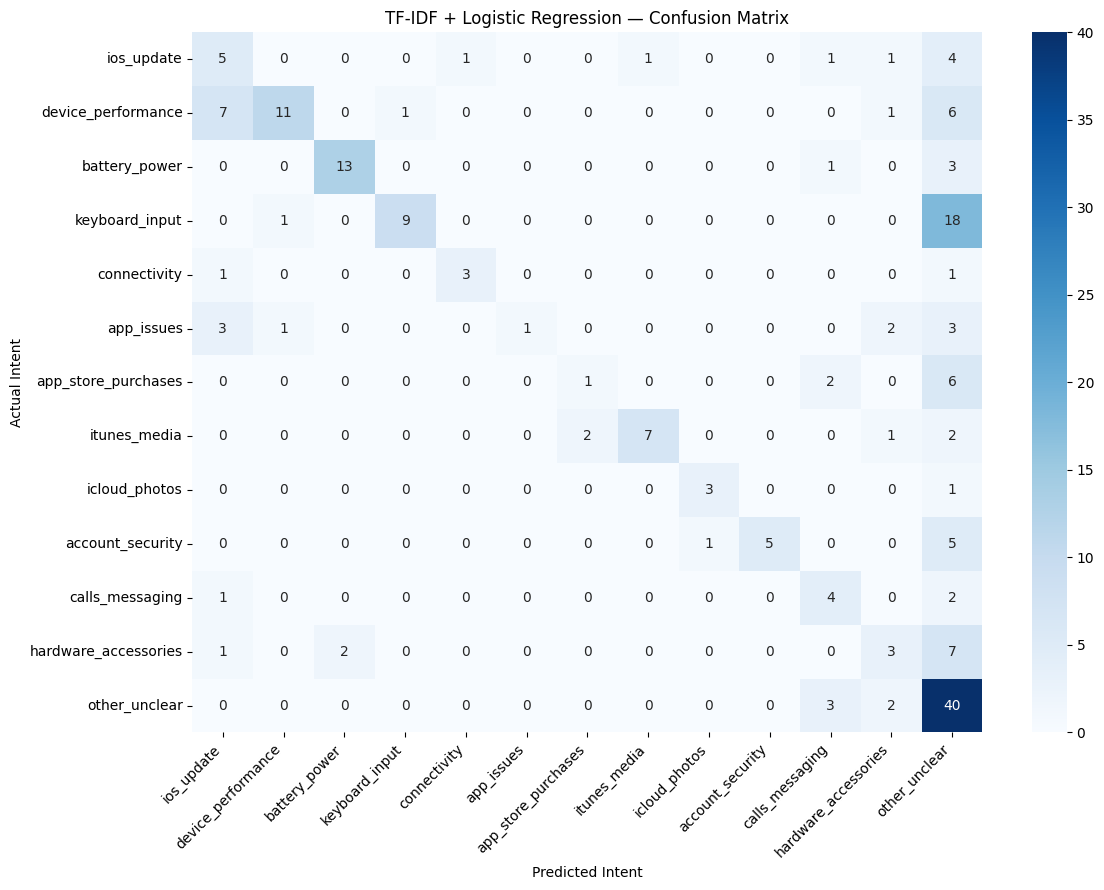

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Keep the same intent order
intent_labels = list(INTENTS.keys())

cm = confusion_matrix(
    y_true,
    y_pred_lr,
    labels=intent_labels
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=intent_labels,
    yticklabels=intent_labels
)

plt.xlabel("Predicted Intent")
plt.ylabel("Actual Intent")
plt.title("TF-IDF + Logistic Regression — Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Failure analysis (TF-IDF baseline).** The largest error mode was `keyboard_input` → `other_unclear` (18 cases): many messages referred indirectly to the known "I" character/autocorrect bug without using the word keyboard, which a lexical model cannot catch. The second was `device_performance` → `ios_update` (7 cases), where update vocabulary dominated even though the complaint was slowness or freezing. `hardware_accessories` and `app_store_purchases` were also absorbed by `other_unclear`, showing the limits of lexical features on vague text.

In [ ]:
# Create a table of all misclassified examples
errors = golden_set[
    golden_set["intent"] != golden_set["predicted_intent"]
].copy()

# Add a useful comparison column
errors["error_type"] = (
    errors["intent"] + " → " + errors["predicted_intent"]
)

# Count the most common error types
top_errors = errors["error_type"].value_counts().head(10)

print("Top Error Types:")
print(top_errors)

Top Error Types:
error_type
keyboard_input → other_unclear          18
hardware_accessories → other_unclear     7
device_performance → ios_update          7
app_store_purchases → other_unclear      6
device_performance → other_unclear       6
account_security → other_unclear         5
ios_update → other_unclear               4
app_issues → other_unclear               3
battery_power → other_unclear            3
other_unclear → calls_messaging          3
Name: count, dtype: int64


In [ ]:
# Show the actual examples for the top 5 error types

top_5_error_types = top_errors.head(5).index

top_5_failures = errors[
    errors["error_type"].isin(top_5_error_types)
][[
    "customer_text",
    "intent",
    "predicted_intent",
    "brand_response"
]]

top_5_failures

,customer_text,intent,predicted_intent,brand_response
0,Clearly need to stop using a first-person pronoun until @115858 can get their shit together.,keyboard_input,other_unclear,@695800 We'd be happy to help. Have you tried the latest update? Make sure you have a backup beforehand: https://t.co/4f8hwT5to6 DM us if that doesn't work. https://t.co/GDrqU22YpT
2,@AppleSupport Why do I get the message that my order# “does not belong to the provided account” when I try to check my iPhone order status?,app_store_purchases,other_unclear,"@574492 We're glad to help in any way we can, or get you pointed in the right direction. Please DM us to proceed from here. https://t.co/GDrqU22YpT"
11,@AppleSupport Kindly fix it.,app_store_purchases,other_unclear,@615781 We're happy to check on this with you. If you go to App Store &gt; Updates do you have any pending? Let us know via DM. https://t.co/GDrqU2kzhr
15,This capital i shit is annoying af. @AppleSupport when y’all fixing this?,keyboard_input,other_unclear,@501931 Here’s what you can do to work around the issue until it’s fixed in a future software update: https://t.co/xXaXeeSRt9
19,@AppleSupport please release an update to speed up iPhone 5S running iOS 11. Laggy OS on 5S is irritating.,device_performance,ios_update,@645454 Thanks for contacting us. That is certainly not an experience we want you to have. Which version of iOS 11 are you running?
20,"@AppleSupport where can i find iOS10 for my iPhone 6? iPhone is completely useless with iOS 11. Consistently hangs, freezes, and crashes and is making my blood boil.",device_performance,ios_update,"@258956 We'd love to work together on this with you. While we do not recommend trying to revert to a previous iOS version, we are more than happy to partner with you and look into solutions for the issues you're experiencing. Join us in DM to get started: https://t.co/GDrqU22YpT"
28,"@AppleSupport Goodmorning! I would like to ask for clarification regarding the skin of which the original covers are made, I would like to know if they are leather or eco-leather or artificial leather.",hardware_accessories,other_unclear,@389306 We would be glad to help clarify this for you. Reach out to us in DM. https://t.co/GDrqU22YpT
29,C’est une blague iOS11 mon iPhone est plus lent qu’un 3GS @AppleSupport allez vous faire enculé,device_performance,other_unclear,@291661 We offer support via Twitter in English. Contact us for help in your preferred language here: https://t.co/IBIY3vMgPj
35,Ok seriously when tf is @115858 going to fix this 👁 shit! It’s annoying af I️m boutta be team #Android,keyboard_input,other_unclear,"@131990 Thanks for reaching out about this situation. Please join us in DM and let us know what version of iOS is installed on your iPhone, you can find out in: Settings &gt; General &gt; About &gt; Version. https://t.co/GDrqU22YpT"
37,@115858 fix the “I️” problem.,keyboard_input,other_unclear,@473167 We're happy to help. DM us so we may better assist you: https://t.co/GDrqU22YpT


## 8. Semantic Classification

In [ ]:
from sentence_transformers import SentenceTransformer

# Load a lightweight pretrained sentence embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded successfully!


In [ ]:
# Make absolutely sure Golden Set examples are excluded
golden_ids = set(golden_set["tweet_id"])

semantic_train = model_data[
    ~model_data["tweet_id"].isin(golden_ids)
].copy()

print("Semantic training examples:", len(semantic_train))
print("Golden evaluation examples:", len(golden_set))

Semantic training examples: 19962
Golden evaluation examples: 200


In [ ]:
# Convert training messages into semantic embeddings

train_embeddings = embedding_model.encode(
    semantic_train["customer_text"].tolist(),
    show_progress_bar=True,
    batch_size=64
)

print("Embedding shape:", train_embeddings.shape)

Batches:   0%|          | 0/312 [00:00<?, ?it/s]

Embedding shape: (19962, 384)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression on semantic embeddings
semantic_classifier = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

semantic_classifier.fit(
    train_embeddings,
    semantic_train["intent"]
)

print("Semantic classifier trained successfully!")

Semantic classifier trained successfully!


In [ ]:
# Convert Golden Set messages into semantic embeddings

golden_embeddings = embedding_model.encode(
    golden_set["customer_text"].tolist(),
    show_progress_bar=True,
    batch_size=64
)

print("Golden embedding shape:", golden_embeddings.shape)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Golden embedding shape: (200, 384)


In [ ]:
# Predict intents for the Golden Evaluation Set
y_pred_semantic = semantic_classifier.predict(golden_embeddings)

# Store predictions
golden_set["predicted_intent_semantic"] = y_pred_semantic

print("Semantic predictions completed:", len(y_pred_semantic))

Semantic predictions completed: 200


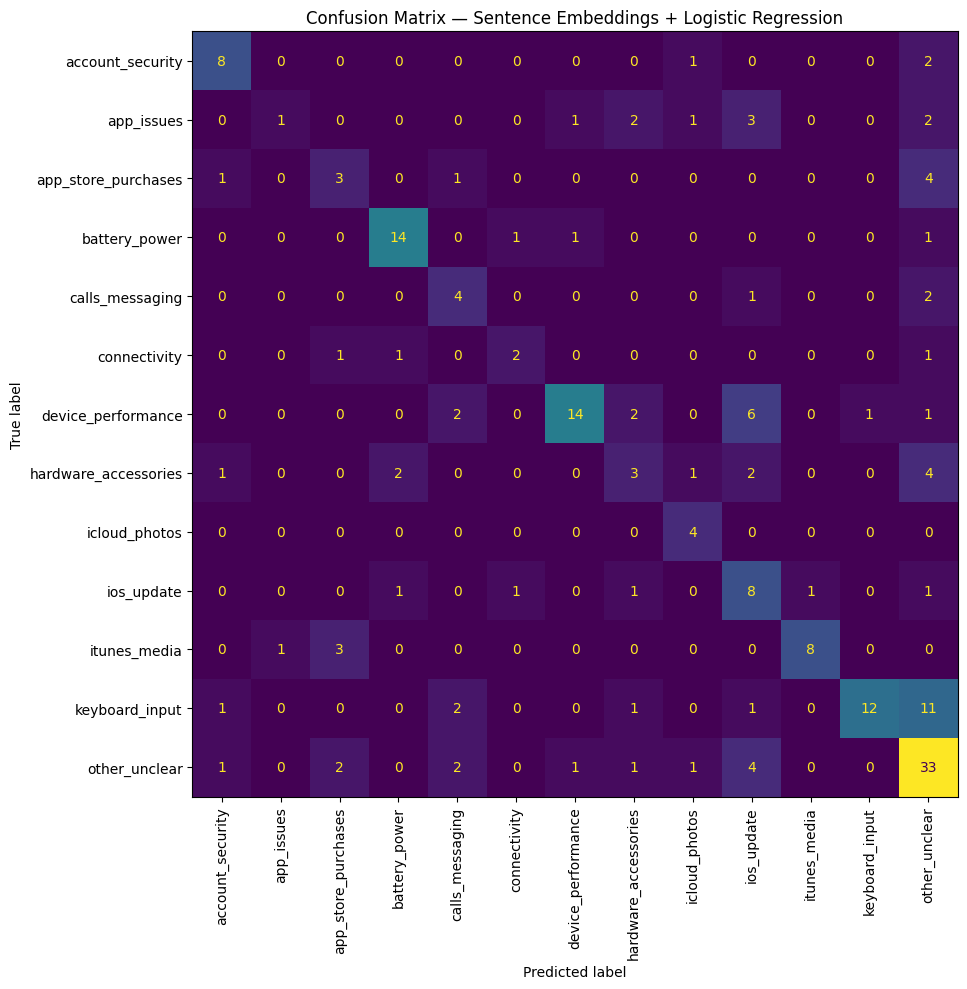

In [ ]:
# ============================================================
# CONFUSION MATRIX — SEMANTIC CLASSIFIER
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred_semantic,
    labels=sorted(INTENTS.keys())
)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(INTENTS.keys())
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d",
    colorbar=False
)

ax.set_title(
    "Confusion Matrix — Sentence Embeddings + Logistic Regression"
)

plt.tight_layout()
plt.show()

### Classification Results — Interpretation

The Sentence Embeddings + Logistic Regression model achieved 57.0%
accuracy and a macro-F1 of 0.527 on the 200-example Golden Set.

The confusion matrix shows that errors are concentrated in a few
ambiguous intent boundaries rather than being uniformly distributed
across all classes.

The largest confusion was `keyboard_input` being predicted as
`other_unclear` (11 cases), followed by `device_performance` being
predicted as `ios_update` (6 cases).

The model performed particularly well on intents such as
`battery_power`, `itunes_media`, `account_security`, and
`icloud_photos`, while weaker performance was observed for
`app_issues`, `hardware_accessories`, and `app_store_purchases`.

This supports using macro-F1 and per-intent metrics alongside overall
accuracy when evaluating the classifier.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# True labels
y_true = golden_set["intent"]

# Semantic model accuracy
semantic_accuracy = accuracy_score(
    y_true,
    y_pred_semantic
)

print("Semantic Embedding + Logistic Regression")
print("=" * 50)
print("Accuracy:", round(semantic_accuracy, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred_semantic,
        zero_division=0
    )
)

print("\nMODEL COMPARISON")
print("=" * 50)
print("Majority baseline:", round(majority_accuracy, 4))
print("TF-IDF + Logistic Regression:", round(lr_accuracy, 4))
print("Semantic + Logistic Regression:", round(semantic_accuracy, 4))

Semantic Embedding + Logistic Regression
Accuracy: 0.57

Classification Report:
                      precision    recall  f1-score   support

    account_security       0.67      0.73      0.70        11
          app_issues       0.50      0.10      0.17        10
 app_store_purchases       0.33      0.33      0.33         9
       battery_power       0.78      0.82      0.80        17
     calls_messaging       0.36      0.57      0.44         7
        connectivity       0.50      0.40      0.44         5
  device_performance       0.82      0.54      0.65        26
hardware_accessories       0.30      0.23      0.26        13
       icloud_photos       0.50      1.00      0.67         4
          ios_update       0.32      0.62      0.42        13
        itunes_media       0.89      0.67      0.76        12
      keyboard_input       0.92      0.43      0.59        28
       other_unclear       0.53      0.73      0.62        45

            accuracy                           0.5

### Zero-shot alternative

In [ ]:
# Create semantic embeddings for our 13 intent descriptions

intent_names = list(INTENTS.keys())
intent_descriptions = list(INTENTS.values())

intent_embeddings = embedding_model.encode(
    intent_descriptions,
    normalize_embeddings=True
)

print("Number of intent descriptions:", len(intent_embeddings))
print("Intent embedding shape:", intent_embeddings.shape)

Number of intent descriptions: 13
Intent embedding shape: (13, 384)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Create embeddings for Golden Set customer messages
golden_zero_embeddings = embedding_model.encode(
    golden_set["customer_text"].tolist(),
    normalize_embeddings=True
)

# Compare every customer message with every intent description
similarity_matrix = cosine_similarity(
    golden_zero_embeddings,
    intent_embeddings
)

# Select the most semantically similar intent
zero_shot_indices = similarity_matrix.argmax(axis=1)

y_pred_zero_shot = [
    intent_names[i]
    for i in zero_shot_indices
]

# Store predictions
golden_set["predicted_intent_zero_shot"] = y_pred_zero_shot

print("Zero-shot predictions completed:", len(y_pred_zero_shot))

Zero-shot predictions completed: 200


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

zero_shot_accuracy = accuracy_score(
    golden_set["intent"],
    y_pred_zero_shot
)

print("Zero-Shot Semantic Classifier")
print("=" * 50)
print("Accuracy:", round(zero_shot_accuracy, 4))

print("\nClassification Report:")
print(
    classification_report(
        golden_set["intent"],
        y_pred_zero_shot,
        zero_division=0
    )
)

print("\nMODEL COMPARISON")
print("=" * 50)
print("Majority baseline:", round(majority_accuracy, 4))
print("TF-IDF + Logistic Regression:", round(lr_accuracy, 4))
print("Semantic + Logistic Regression:", round(semantic_accuracy, 4))
print("Zero-Shot Semantic:", round(zero_shot_accuracy, 4))

Zero-Shot Semantic Classifier
Accuracy: 0.39

Classification Report:
                      precision    recall  f1-score   support

    account_security       0.29      0.91      0.43        11
          app_issues       0.33      0.10      0.15        10
 app_store_purchases       0.50      0.11      0.18         9
       battery_power       0.82      0.53      0.64        17
     calls_messaging       0.18      0.43      0.25         7
        connectivity       1.00      0.60      0.75         5
  device_performance       0.80      0.31      0.44        26
hardware_accessories       0.60      0.23      0.33        13
       icloud_photos       0.57      1.00      0.73         4
          ios_update       0.18      0.69      0.29        13
        itunes_media       0.65      0.92      0.76        12
      keyboard_input       0.46      0.57      0.51        28
       other_unclear       0.00      0.00      0.00        45

            accuracy                           0.39       200

#A zero-shot semantic matching approach using cosine similarity between customer-message embeddings and intent-description embeddings was evaluated. It achieved 39% accuracy, substantially below both TF-IDF + Logistic Regression (52.5%) and supervised semantic embeddings + Logistic Regression (57%). This indicated that generic intent descriptions were insufficient for reliable zero-shot classification on this dataset

## 9. AUTO / ESCALATE Policy

## 10. Golden Set Evaluation

In [ ]:
response_eval = golden_set[
    [
        "tweet_id",
        "customer_text",
        "intent",
        "handling"
    ]
].copy()

response_eval = response_eval.rename(columns={
    "intent": "true_intent",
    "handling": "true_handling"
})

response_eval["predicted_intent"] = None
response_eval["predicted_handling"] = None
response_eval["handling_reason"] = None
response_eval["retrieved_response"] = None
response_eval["generated_response"] = None

response_eval["relevance"] = None
response_eval["groundedness"] = None
response_eval["helpfulness"] = None
response_eval["tone"] = None
response_eval["no_unsupported_claims"] = None
response_eval["overall_score"] = None

print("Rows:", len(response_eval))
print("\nColumns:")
print(response_eval.columns.tolist())

display(response_eval.head())

Rows: 200

Columns:
['tweet_id', 'customer_text', 'true_intent', 'true_handling', 'predicted_intent', 'predicted_handling', 'handling_reason', 'retrieved_response', 'generated_response', 'relevance', 'groundedness', 'helpfulness', 'tone', 'no_unsupported_claims', 'overall_score']


,tweet_id,customer_text,true_intent,true_handling,predicted_intent,predicted_handling,handling_reason,retrieved_response,generated_response,relevance,groundedness,helpfulness,tone,no_unsupported_claims,overall_score
0,2422571,Clearly need to stop using a first-person pronoun until @115858 can get their shit together.,keyboard_input,AUTO,None,None,None,None,None,None,None,None,None,None,None
1,2299863,"@AppleSupport Yes, and I filed a radar",other_unclear,ESCALATE,None,None,None,None,None,None,None,None,None,None,None
2,1930614,@AppleSupport Why do I get the message that my order# “does not belong to the provided account” when I try to check my iPhone order status?,app_store_purchases,ESCALATE,None,None,None,None,None,None,None,None,None,None,None
3,921012,@AppleSupport please fix this with the next ios 11 update https://t.co/tajxvdLag7,ios_update,AUTO,None,None,None,None,None,None,None,None,None,None,None
4,2555259,"@AppleSupport I restored to iPhone X, latest version of iOS and everything restored, except for some of my health data from the last week. Any thoughts?",icloud_photos,ESCALATE,None,None,None,None,None,None,None,None,None,None,None


In [ ]:
def get_handling_reason(predicted_intent):

    if predicted_intent in AUTO_INTENTS:
        return (
            "AUTO: this intent is included in the predefined "
            "auto-handle policy."
        )

    return (
        "ESCALATE: this intent is not included in the predefined "
        "auto-handle policy."
    )

In [ ]:
# Generate predictions for the entire Golden Set

golden_embeddings = embedding_model.encode(
    golden_set["customer_text"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True,
    batch_size=64
)

golden_predicted_intents = semantic_classifier.predict(
    golden_embeddings
)

golden_probabilities = semantic_classifier.predict_proba(
    golden_embeddings
)

golden_confidence = golden_probabilities.max(axis=1)

response_eval["predicted_intent"] = golden_predicted_intents
response_eval["confidence"] = golden_confidence

response_eval["predicted_handling"] = response_eval[
    "predicted_intent"
].apply(decide_handling)

response_eval["handling_reason"] = response_eval[
    "predicted_intent"
].apply(get_handling_reason)

print("Evaluation table created.")
print("Rows:", len(response_eval))

display(
    response_eval[
        [
            "customer_text",
            "true_intent",
            "predicted_intent",
            "confidence",
            "true_handling",
            "predicted_handling",
            "handling_reason"
        ]
    ].head(10)
)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Evaluation table created.
Rows: 200


,customer_text,true_intent,predicted_intent,confidence,true_handling,predicted_handling,handling_reason
0,Clearly need to stop using a first-person pronoun until @115858 can get their shit together.,keyboard_input,other_unclear,0.675493,AUTO,ESCALATE,ESCALATE: this intent is not included in the predefined auto-handle policy.
1,"@AppleSupport Yes, and I filed a radar",other_unclear,other_unclear,0.910650,ESCALATE,ESCALATE,ESCALATE: this intent is not included in the predefined auto-handle policy.
2,@AppleSupport Why do I get the message that my order# “does not belong to the provided account” when I try to check my iPhone order status?,app_store_purchases,app_store_purchases,0.379585,ESCALATE,ESCALATE,ESCALATE: this intent is not included in the predefined auto-handle policy.
3,@AppleSupport please fix this with the next ios 11 update https://t.co/tajxvdLag7,ios_update,ios_update,0.973923,AUTO,ESCALATE,ESCALATE: this intent is not included in the predefined auto-handle policy.
4,"@AppleSupport I restored to iPhone X, latest version of iOS and everything restored, except for some of my health data from the last week. Any thoughts?",icloud_photos,icloud_photos,0.564030,ESCALATE,ESCALATE,ESCALATE: this intent is not included in the predefined auto-handle policy.
5,@AppleSupport yes. It doesn’t even open completely.,app_issues,other_unclear,0.720622,ESCALATE,ESCALATE,ESCALATE: this intent is not included in the predefined auto-handle policy.
6,Currently:_ Is @AppleSupport just going to ignore the fact that ALL PHONES are experiencing this question mark issue when you put “ I️ “,keyboard_input,keyboard_input,0.939856,AUTO,AUTO,AUTO: this intent is included in the predefined auto-handle policy.
7,@115858 why is it I can’t delete my credit card off my phone? I have a big issue with this,app_store_purchases,other_unclear,0.277230,ESCALATE,ESCALATE,ESCALATE: this intent is not included in the predefined auto-handle policy.
8,@AppleSupport Figured out the problem - it was being blocked by a content blocker. Choosing Reload without Content Blockers solved it.,other_unclear,other_unclear,0.213156,AUTO,ESCALATE,ESCALATE: this intent is not included in the predefined auto-handle policy.
9,#iOS11 update is been a disaster for me. Never thought an #iPhone could hang and become unresponsive. I use an #iPhone6. Anyone else? @115858,device_performance,calls_messaging,0.517473,AUTO,ESCALATE,ESCALATE: this intent is not included in the predefined auto-handle policy.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_true = response_eval["true_intent"]
y_pred = response_eval["predicted_intent"]

classification_accuracy = accuracy_score(y_true, y_pred)

print("SEMANTIC CLASSIFIER RESULTS")
print("=" * 50)
print("Accuracy:", round(classification_accuracy, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        zero_division=0
    )
)

SEMANTIC CLASSIFIER RESULTS
Accuracy: 0.57

Classification Report:
                      precision    recall  f1-score   support

    account_security       0.67      0.73      0.70        11
          app_issues       0.50      0.10      0.17        10
 app_store_purchases       0.33      0.33      0.33         9
       battery_power       0.78      0.82      0.80        17
     calls_messaging       0.36      0.57      0.44         7
        connectivity       0.50      0.40      0.44         5
  device_performance       0.82      0.54      0.65        26
hardware_accessories       0.30      0.23      0.26        13
       icloud_photos       0.50      1.00      0.67         4
          ios_update       0.32      0.62      0.42        13
        itunes_media       0.89      0.67      0.76        12
      keyboard_input       0.92      0.43      0.59        28
       other_unclear       0.53      0.73      0.62        45

            accuracy                           0.57       200
 

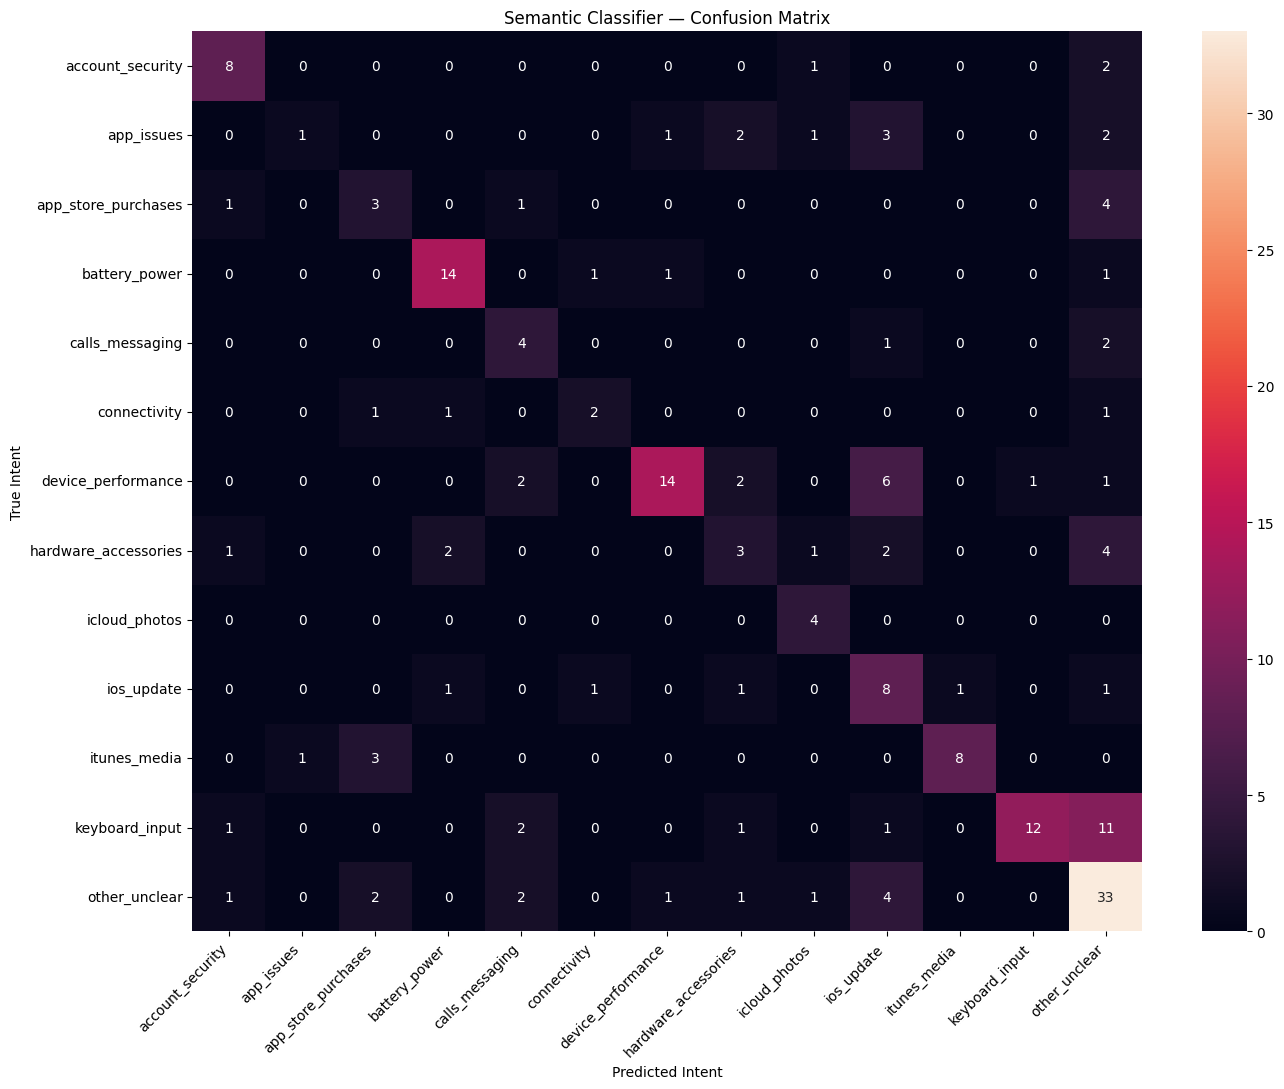

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = sorted(response_eval["true_intent"].unique())

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Intent")
plt.ylabel("True Intent")
plt.title("Semantic Classifier — Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Find the most common classification errors

errors = response_eval[
    response_eval["true_intent"] != response_eval["predicted_intent"]
].copy()

error_pairs = (
    errors
    .groupby(["true_intent", "predicted_intent"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("TOP CLASSIFICATION ERROR PAIRS")
print("=" * 60)

display(error_pairs.head(10))

TOP CLASSIFICATION ERROR PAIRS


,true_intent,predicted_intent,count
39,keyboard_input,other_unclear,11
20,device_performance,ios_update,6
9,app_store_purchases,other_unclear,4
27,hardware_accessories,other_unclear,4
46,other_unclear,ios_update,4
5,app_issues,ios_update,3
34,itunes_media,app_store_purchases,3
18,device_performance,calls_messaging,2
19,device_performance,hardware_accessories,2
24,hardware_accessories,battery_power,2


In [ ]:
top5_pairs = error_pairs.head(5)

for _, row in top5_pairs.iterrows():

    true_label = row["true_intent"]
    predicted_label = row["predicted_intent"]

    print("\n" + "=" * 80)
    print(
        f"TRUE: {true_label}  →  "
        f"PREDICTED: {predicted_label}  "
        f"({row['count']} errors)"
    )
    print("=" * 80)

    examples = errors[
        (errors["true_intent"] == true_label) &
        (errors["predicted_intent"] == predicted_label)
    ].head(3)

    for i, (_, example) in enumerate(examples.iterrows(), 1):

        print(f"\nExample {i}:")
        print("Customer:", example["customer_text"])
        print("Confidence:", round(example["confidence"], 3))


TRUE: keyboard_input  →  PREDICTED: other_unclear  (11 errors)

Example 1:
Customer: Clearly need to stop using a first-person pronoun until @115858 can get their shit together.
Confidence: 0.675

Example 2:
Customer: This capital i shit is annoying af. @AppleSupport when y’all fixing this?
Confidence: 0.733

Example 3:
Customer: Ok seriously when tf is @115858 going to fix this 👁 shit! It’s annoying af I️m boutta be team #Android
Confidence: 0.65

TRUE: device_performance  →  PREDICTED: ios_update  (6 errors)

Example 1:
Customer: @AppleSupport please release an update to speed up iPhone 5S running iOS 11. Laggy OS on 5S is irritating.
Confidence: 0.796

Example 2:
Customer: @AppleSupport where can i find iOS10 for my iPhone 6?  iPhone is completely useless with iOS 11. Consistently hangs, freezes, and crashes and is making my blood boil.
Confidence: 0.426

Example 3:
Customer: Hasn’t been 6months since I got my Iphone 6s and its beenhanging. These new updates suck. #Apple #Getyoursh

In [ ]:
# Create a report-ready Top-5 failure analysis table

top5_failure_rows = []

for _, row in error_pairs.head(5).iterrows():

    true_label = row["true_intent"]
    predicted_label = row["predicted_intent"]

    examples = errors[
        (errors["true_intent"] == true_label) &
        (errors["predicted_intent"] == predicted_label)
    ].head(3)

    for _, example in examples.iterrows():

        top5_failure_rows.append({
            "true_intent": true_label,
            "predicted_intent": predicted_label,
            "error_count": int(row["count"]),
            "customer_text": example["customer_text"],
            "confidence": round(example["confidence"], 3)
        })

top5_failure_df = pd.DataFrame(top5_failure_rows)

display(top5_failure_df)

,true_intent,predicted_intent,error_count,customer_text,confidence
0,keyboard_input,other_unclear,11,Clearly need to stop using a first-person pronoun until @115858 can get their shit together.,0.675
1,keyboard_input,other_unclear,11,This capital i shit is annoying af. @AppleSupport when y’all fixing this?,0.733
2,keyboard_input,other_unclear,11,Ok seriously when tf is @115858 going to fix this 👁 shit! It’s annoying af I️m boutta be team #Android,0.650
3,device_performance,ios_update,6,@AppleSupport please release an update to speed up iPhone 5S running iOS 11. Laggy OS on 5S is irritating.,0.796
4,device_performance,ios_update,6,"@AppleSupport where can i find iOS10 for my iPhone 6? iPhone is completely useless with iOS 11. Consistently hangs, freezes, and crashes and is making my blood boil.",0.426
5,device_performance,ios_update,6,Hasn’t been 6months since I got my Iphone 6s and its beenhanging. These new updates suck. #Apple #Getyourshittogether @115858 @AppleSupport,0.308
6,app_store_purchases,other_unclear,4,@115858 why is it I can’t delete my credit card off my phone? I have a big issue with this,0.277
7,app_store_purchases,other_unclear,4,@AppleSupport Kindly fix it.,0.844
8,app_store_purchases,other_unclear,4,@AppleSupport I was not able to track down any UK contact info using this webpage. Please see below the screenshots for the info that i have on my order. https://t.co/1yevU08nf1,0.216
9,hardware_accessories,other_unclear,4,@AppleSupport I️ shouldn’t have to fix apples mistakes. Also where is my iwatch it was stolen can I️ get help locating it or reporting it stolen,0.351


In [ ]:
# Compare all classification models on the Golden Set
y_pred_tfidf = tfidf_lr.predict(golden_set["customer_text"])

metric_comparison = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "TF-IDF + Logistic Regression",
        "Semantic Embedding + Logistic Regression"
    ],
    "Accuracy": [
        majority_accuracy,
        accuracy_score(y_true, y_pred_tfidf),
        accuracy_score(y_true, y_pred_semantic)
    ],
    "Macro F1": [
        f1_score(y_true, y_pred_majority, average="macro"),
        f1_score(y_true, y_pred_tfidf, average="macro"),
        f1_score(y_true, y_pred_semantic, average="macro")
    ],
    "Weighted F1": [
        f1_score(y_true, y_pred_majority, average="weighted"),
        f1_score(y_true, y_pred_tfidf, average="weighted"),
        f1_score(y_true, y_pred_semantic, average="weighted")
    ]
})

metric_comparison

,Model,Accuracy,Macro F1,Weighted F1
0,Majority Baseline,0.225,0.028257,0.082653
1,TF-IDF + Logistic Regression,0.525,0.502136,0.512698
2,Semantic Embedding + Logistic Regression,0.570,0.526799,0.565021


In [ ]:
handling_by_intent = pd.crosstab(
    golden_set["intent"],
    golden_set["handling"]
)

print(handling_by_intent)

handling              AUTO  ESCALATE
intent                              
account_security         4         7
app_issues               2         8
app_store_purchases      1         8
battery_power            3        14
calls_messaging          2         5
connectivity             2         3
device_performance       5        21
hardware_accessories     2        11
icloud_photos            1         3
ios_update               5         8
itunes_media             5         7
keyboard_input          26         2
other_unclear           11        34


In [ ]:
# Calculate how often each intent was labelled AUTO
handling_summary = handling_by_intent.copy()

handling_summary["total"] = (
    handling_summary["AUTO"] +
    handling_summary["ESCALATE"]
)

handling_summary["auto_rate"] = (
    handling_summary["AUTO"] /
    handling_summary["total"]
)

handling_summary = handling_summary.sort_values(
    "auto_rate",
    ascending=False
)

print(handling_summary)

handling              AUTO  ESCALATE  total  auto_rate
intent                                                
keyboard_input          26         2     28   0.928571
itunes_media             5         7     12   0.416667
connectivity             2         3      5   0.400000
ios_update               5         8     13   0.384615
account_security         4         7     11   0.363636
calls_messaging          2         5      7   0.285714
icloud_photos            1         3      4   0.250000
other_unclear           11        34     45   0.244444
app_issues               2         8     10   0.200000
device_performance       5        21     26   0.192308
battery_power            3        14     17   0.176471
hardware_accessories     2        11     13   0.153846
app_store_purchases      1         8      9   0.111111


In [ ]:
# Conservative AUTO / ESCALATE policy

AUTO_INTENTS = {
    "keyboard_input",
    "itunes_media",
    "connectivity"
}

def decide_handling(predicted_intent):
    if predicted_intent in AUTO_INTENTS:
        return "AUTO"
    return "ESCALATE"

# Apply policy using semantic model predictions
golden_set["predicted_handling"] = (
    golden_set["predicted_intent_semantic"]
    .apply(decide_handling)
)

print(golden_set["predicted_handling"].value_counts())

predicted_handling
ESCALATE    174
AUTO         26
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

handling_accuracy = accuracy_score(
    golden_set["handling"],
    golden_set["predicted_handling"]
)

print("Handling Decision Results")
print("=" * 45)
print("Accuracy:", round(handling_accuracy, 4))

print("\nClassification Report:")
print(
    classification_report(
        golden_set["handling"],
        golden_set["predicted_handling"],
        zero_division=0
    )
)

Handling Decision Results
Accuracy: 0.685

Classification Report:
              precision    recall  f1-score   support

        AUTO       0.62      0.23      0.34        69
    ESCALATE       0.70      0.92      0.79       131

    accuracy                           0.69       200
   macro avg       0.66      0.58      0.57       200
weighted avg       0.67      0.69      0.64       200



**Caveat on the handling accuracy.** The `AUTO_INTENTS` set was chosen after inspecting the per-intent AUTO rates in the Golden Set, and it is then evaluated on that same Golden Set. The resulting handling accuracy is therefore an in-sample estimate of the policy and should not be read as independent held-out performance. A clean number would require a second labelled set annotated after the policy was fixed.

## 11. Historical Response Retrieval

In [ ]:
# Create embeddings for historical customer messages
# These will be used for semantic retrieval

historical_embeddings = train_embeddings

historical_responses = semantic_train["brand_response"].tolist()
historical_questions = semantic_train["customer_text"].tolist()

print("Historical conversations:", len(historical_questions))
print("Embedding matrix:", historical_embeddings.shape)

Historical conversations: 19962
Embedding matrix: (19962, 384)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def retrieve_similar_cases(customer_text, top_k=3):
    # Convert new customer message into an embedding
    query_embedding = embedding_model.encode(
        [customer_text],
        normalize_embeddings=True
    )

    # Calculate similarity with all historical customer messages
    similarities = cosine_similarity(
        query_embedding,
        historical_embeddings
    )[0]

    # Get indices of the most similar cases
    top_indices = np.argsort(similarities)[::-1][:top_k]

    # Build results
    results = []

    for idx in top_indices:
        results.append({
            "customer_message": historical_questions[idx],
            "brand_response": historical_responses[idx],
            "similarity": float(similarities[idx])
        })

    return results

print("Retrieval function created successfully!")

Retrieval function created successfully!


In [ ]:
import re

def clean_tweet_text(text):
    if not isinstance(text, str):
        return ""

    # Remove Twitter @mentions
    text = re.sub(r'@\w+', '', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Clean historical AppleSupport responses
cleaned_historical_responses = [
    clean_tweet_text(response)
    for response in historical_responses
]

print("Original:")
print(historical_responses[0])

print("\nCleaned:")
print(cleaned_historical_responses[0])

Original:
@249088 We're happy to help! Please check out the following article: https://t.co/osZOKKTalm If you need to update the iOS be sure to create a backup before beginning. DM us if you have additional questions. https://t.co/GDrqU22YpT

Cleaned:
We're happy to help! Please check out the following article: If you need to update the iOS be sure to create a backup before beginning. DM us if you have additional questions.


In [ ]:
def support_agent_retrieve(customer_text, top_k=3):
    # 1. Predict intent
    query_embedding = embedding_model.encode(
        [customer_text],
        normalize_embeddings=True
    )

    predicted_intent = semantic_classifier.predict(
        query_embedding
    )[0]

    # 2. Decide AUTO / ESCALATE
    handling = decide_handling(predicted_intent)

    # 3. Retrieve similar historical cases
    similarities = cosine_similarity(
        query_embedding,
        historical_embeddings
    )[0]

    top_indices = np.argsort(similarities)[::-1][:top_k]

    retrieved_cases = []

    for idx in top_indices:
        retrieved_cases.append({
            "customer_message": historical_questions[idx],
            "brand_response": cleaned_historical_responses[idx],
            "similarity": float(similarities[idx])
        })

    return {
        "customer_text": customer_text,
        "predicted_intent": predicted_intent,
        "handling": handling,
        "retrieved_cases": retrieved_cases
    }

print("Support-agent retrieval pipeline created!")

Support-agent retrieval pipeline created!


In [ ]:
# Test the complete support-agent pipeline

test_message = golden_set.iloc[0]["customer_text"]

result = support_agent_retrieve(test_message, top_k=3)

print("CUSTOMER:")
print(result["customer_text"])

print("\nPREDICTED INTENT:")
print(result["predicted_intent"])

print("\nHANDLING DECISION:")
print(result["handling"])

print("\nRETRIEVED HISTORICAL CASES:")

for i, case in enumerate(result["retrieved_cases"], 1):
    print(f"\n--- Case {i} ---")
    print("Similarity:", round(case["similarity"], 3))
    print("Customer:", case["customer_message"])
    print("AppleSupport:", case["brand_response"])

CUSTOMER:
Clearly need to stop using a first-person pronoun until @115858 can get their shit together.

PREDICTED INTENT:
other_unclear

HANDLING DECISION:
ESCALATE

RETRIEVED HISTORICAL CASES:

--- Case 1 ---
Similarity: 0.687
Customer: @115858 eye am sick of not being able to type my own pronoun correctly ... when’s this fix coming dudes??
AppleSupport: Here’s what you can do to work around the issue until it’s fixed in a future software update:

--- Case 2 ---
Similarity: 0.668
Customer: @115858 HELP. LOSING MY DAMN MIND AND CAN’T TYPE THE PRONOUN REFERRING TO MYSELF. I️
AppleSupport: Let's take a look at this together. Have you updated your iPhone to iOS 11.1? Let us know in DM and we'll get started.

--- Case 3 ---
Similarity: 0.666
Customer: Everyone’s typing “I️” instead of “i”. @115858 needs to get there shit straight. Smh
AppleSupport: Please update the device to the latest version of iOS, 11.1.1. This will resolve this issue. Remember to back up your device first. How to back

### Retrieval quality

In [ ]:
# Generate retrieval-based responses for the 200 Golden examples
# No Gemini/API calls are made here.

retrieval_results = []

for _, row in tqdm(
    golden_set.iterrows(),
    total=len(golden_set),
    desc="Retrieving historical responses"
):
    result = support_agent_retrieve(
        row["customer_text"],
        top_k=3
    )

    best_case = result["retrieved_cases"][0]

    retrieval_results.append({
        "tweet_id": row["tweet_id"],
        "retrieved_response": best_case["brand_response"],
        "retrieval_similarity": best_case["similarity"],
        "retrieved_customer_message": best_case["customer_message"]
    })

retrieval_df = pd.DataFrame(retrieval_results)

# Add retrieval results to the evaluation dataframe
response_eval = response_eval.drop(
    columns=[
        "retrieved_response",
        "retrieval_similarity",
        "retrieved_customer_message"
    ],
    errors="ignore"
)

response_eval = response_eval.merge(
    retrieval_df,
    on="tweet_id",
    how="left"
)

print("Retrieved responses:", response_eval["retrieved_response"].notna().sum())

Retrieving historical responses:   0%|          | 0/200 [00:00<?, ?it/s]

Retrieved responses: 200


In [ ]:
# Retrieval similarity statistics

retrieval_stats = response_eval["retrieval_similarity"].describe()

print("Retrieval similarity statistics:")
display(retrieval_stats)

print("\nAverage similarity:",
      round(response_eval["retrieval_similarity"].mean(), 3))

print("Median similarity:",
      round(response_eval["retrieval_similarity"].median(), 3))

print("Minimum similarity:",
      round(response_eval["retrieval_similarity"].min(), 3))

print("Maximum similarity:",
      round(response_eval["retrieval_similarity"].max(), 3))

Retrieval similarity statistics:


,retrieval_similarity
count,200.000000
mean,0.791210
std,0.093947
min,0.448968
25%,0.731584
50%,0.791355
75%,0.847227
max,1.000000



Average similarity: 0.791
Median similarity: 0.791
Minimum similarity: 0.449
Maximum similarity: 1.0


In [ ]:
# Inspect 10 Golden examples and their retrieved historical responses

display(
    response_eval[
        [
            "customer_text",
            "true_intent",
            "predicted_intent",
            "retrieval_similarity",
            "retrieved_customer_message",
            "retrieved_response"
        ]
    ].head(10)
)

,customer_text,true_intent,predicted_intent,retrieval_similarity,retrieved_customer_message,retrieved_response
0,Clearly need to stop using a first-person pronoun until @115858 can get their shit together.,keyboard_input,other_unclear,0.687385,@115858 eye am sick of not being able to type my own pronoun correctly ... when’s this fix coming dudes??,Here’s what you can do to work around the issue until it’s fixed in a future software update:
1,"@AppleSupport Yes, and I filed a radar",other_unclear,other_unclear,0.762493,@AppleSupport Having the same issue too. I opened a radar #34904227,"If you're having issues with Handoff, go ahead and meet us within DM here:"
2,@AppleSupport Why do I get the message that my order# “does not belong to the provided account” when I try to check my iPhone order status?,app_store_purchases,app_store_purchases,0.727505,@AppleSupport I have a problem with an order on the Apple Store online.,DM us the country where you are located and we can go from there.
3,@AppleSupport please fix this with the next ios 11 update https://t.co/tajxvdLag7,ios_update,ios_update,0.889186,@249128 @AppleSupport It seems updating to iOS 11.2 has fixed it. Thanks.,"Great, if you need help in the future, feel free to let us know."
4,"@AppleSupport I restored to iPhone X, latest version of iOS and everything restored, except for some of my health data from the last week. Any thoughts?",icloud_photos,icloud_photos,0.710567,@AppleSupport I used iCloud restore to my iPhone X and have virtually no historical health data. How do I transfer it from my 📱7 iOS11.1?,Happy to look into this with you. Do you still have your iPhone 7 with you? DM us and let us know.
5,@AppleSupport yes. It doesn’t even open completely.,app_issues,other_unclear,0.757483,@AppleSupport Yes only there,OK got it. Have you tried connecting to Wi-Fi?
6,Currently:_ Is @AppleSupport just going to ignore the fact that ALL PHONES are experiencing this question mark issue when you put “ I️ “,keyboard_input,keyboard_input,0.798272,@AppleSupport why do question marks keep appearing every time I️ type “I️” . I’ve reset my phone already.,"We'd like to look into this with you. To begin, what device and operating system are you using?"
7,@115858 why is it I can’t delete my credit card off my phone? I have a big issue with this,app_store_purchases,other_unclear,0.643735,@AppleSupport when I try to remove my credit card off my iTunes account it doesn't let me save the changes it says an unknown error has occurred; I would like to remove my credit card please!,We'd like to look into that with you. What type of device are you using to try and update your payment information? Please let us know in DM.
8,@AppleSupport Figured out the problem - it was being blocked by a content blocker. Choosing Reload without Content Blockers solved it.,other_unclear,other_unclear,0.748059,@AppleSupport This happens or it says content can’t be played. https://t.co/IipojSHqU5,Thanks for the photo. We want to look further into this issue. Reach us via DM to continue.
9,#iOS11 update is been a disaster for me. Never thought an #iPhone could hang and become unresponsive. I use an #iPhone6. Anyone else? @115858,device_performance,calls_messaging,0.826721,"@AppleSupport @116333 @797 since ios11 update I started hating my Iphone 6 .. it hangs, stops and what not .. contact me",This is certainly not the behavior we want you to experience. We want to help! Could you DM us which iOS 11 version you're using? Here's a link to help locate your iOS version: We look forward to speaking with you soon.


In [ ]:
# Build a mapping from historical customer message -> intent
# using the labelled training data.

historical_intent_lookup = dict(
    zip(
        semantic_train["customer_text"],
        semantic_train["intent"]
    )
)

# Determine the intent of each retrieved historical example
response_eval["retrieved_intent"] = (
    response_eval["retrieved_customer_message"]
    .map(historical_intent_lookup)
)

# Compare retrieved intent with the human Golden intent
response_eval["retrieval_intent_match"] = (
    response_eval["true_intent"] ==
    response_eval["retrieved_intent"]
)

print(
    "Retrieved cases with known intent:",
    response_eval["retrieved_intent"].notna().sum()
)

print(
    "Top-1 intent-consistent retrievals:",
    response_eval["retrieval_intent_match"].sum()
)

print(
    "Top-1 retrieval intent consistency:",
    round(
        response_eval["retrieval_intent_match"].mean() * 100,
        2
    ),
    "%"
)

Retrieved cases with known intent: 200
Top-1 intent-consistent retrievals: 87
Top-1 retrieval intent consistency: 43.5 %


This is **top-1 retrieval intent consistency** — how often the single most similar historical case shares the human-assigned intent of the query — and not retrieval accuracy. A retrieved case can carry a useful response even when its intent label differs, and the historical labels themselves are silver (keyword-derived), not human-verified.

## 12. Response Generation

A small local model (FLAN-T5-small) was tried first, then Gemini.

In [ ]:
print("generation_eval rows:", len(generation_eval))

print(
    "Generated responses:",
    generation_eval["generated_response"].notna().sum()
)

generation_eval rows: 30
Generated responses: 0


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "google/flan-t5-small"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

generator_model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME
)

print("Generation model loaded successfully!")

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Generation model loaded successfully!


In [ ]:
def generate_flan_response(customer_text, top_k=3):
    # Retrieve similar historical cases
    result = support_agent_retrieve(
        customer_text,
        top_k=top_k
    )

    # Use the most relevant historical response
    best_case = result["retrieved_cases"][0]

    historical_response = best_case["brand_response"]

    # Much simpler prompt for the small FLAN-T5 model
    prompt = f"""
Customer problem: {customer_text}

A previous AppleSupport response to a similar problem was:
{historical_response}

Write a short helpful customer-support reply based ONLY on that previous response.
Do not mention this prompt.
Do not repeat the instructions.
Do not invent new troubleshooting steps.
Reply directly to the customer.

Answer:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=384
    )

    outputs = generator_model.generate(
        **inputs,
        max_new_tokens=80,
        num_beams=4,
        no_repeat_ngram_size=3,
        early_stopping=True
    )

    generated_response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    ).strip()

    return {
        "customer_text": customer_text,
        "predicted_intent": result["predicted_intent"],
        "handling": result["handling"],
        "retrieved_cases": result["retrieved_cases"],
        "generated_response": generated_response
    }

print("FLAN-T5 response generator created!")

FLAN-T5 response generator created!


In [ ]:
# Test the FLAN-T5 generator on a Golden Set message

generated_result = generate_flan_response(
    golden_set.iloc[0]["customer_text"],
    top_k=3
)

print("CUSTOMER:")
print(generated_result["customer_text"])

print("\nPREDICTED INTENT:")
print(generated_result["predicted_intent"])

print("\nHANDLING:")
print(generated_result["handling"])

print("\nGENERATED RESPONSE:")
print(generated_result["generated_response"])

print("\nBEST HISTORICAL RESPONSE:")
print(generated_result["retrieved_cases"][0]["brand_response"])

CUSTOMER:
Clearly need to stop using a first-person pronoun until @115858 can get their shit together.

PREDICTED INTENT:
other_unclear

HANDLING:
ESCALATE

GENERATED RESPONSE:
Thanks for your help. I'm sorry to hear that.

BEST HISTORICAL RESPONSE:
Here’s what you can do to work around the issue until it’s fixed in a future software update:


FLAN-T5-small produced fragmented, low-quality replies, so generation was moved to Gemini with the same grounding constraints.

In [ ]:
from google.colab import userdata
from google import genai

api_key = userdata.get("GEMINI_API_KEY")

client = genai.Client(api_key=api_key)

print("Gemini client initialized successfully!")

Gemini client initialized successfully!


In [ ]:
# ============================================================
# BACKUP GEMINI PROGRESS TO GOOGLE DRIVE
# ============================================================

from google.colab import drive
import os
import shutil

drive.mount("/content/drive")

BACKUP_DIR = "/content/drive/MyDrive/AppleSupport_Agent"
os.makedirs(BACKUP_DIR, exist_ok=True)

if os.path.exists("generation_eval_progress.csv"):

    shutil.copy2(
        "generation_eval_progress.csv",
        os.path.join(
            BACKUP_DIR,
            "generation_eval_progress.csv"
        )
    )

    print("Progress backup saved to Google Drive.")
    print(
        "Generated responses:",
        generation_eval["generated_response"].notna().sum(),
        "/",
        len(generation_eval)
    )

    judge_columns = [
        "relevance",
        "groundedness",
        "helpfulness",
        "tone",
        "no_unsupported_claims"
    ]

    print(
        "LLM judge results:",
        generation_eval[judge_columns].notna().all(axis=1).sum(),
        "/",
        len(generation_eval)
    )

else:
    print("No progress file found. Nothing to back up.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Progress backup saved to Google Drive.
Generated responses: 17 / 30
LLM judge results: 1 / 30


In [ ]:
# Select a small controlled subset for response-generation evaluation

GENERATION_EVAL_SIZE = 30

generation_eval = response_eval.sample(
    GENERATION_EVAL_SIZE,
    random_state=2026
).copy().reset_index(drop=True)

print("Generation evaluation examples:", len(generation_eval))

display(
    generation_eval[
        [
            "customer_text",
            "true_intent",
            "predicted_intent",
            "retrieved_response"
        ]
    ].head()
)

Generation evaluation examples: 30


,customer_text,true_intent,predicted_intent,retrieved_response
0,@AppleSupport Hard reset didn’t work and it crashes so much it’s hard to even use to check stuff. It’s updated though I checked. Took off all recent apps but still doing it.,device_performance,device_performance,Let's pair up in DM to get a closer look at what you're seeing here.
1,@AppleSupport when will the auto-capitalizing “It” and I️ that changed to “A ?” be fixed?! This is super annoying!,keyboard_input,keyboard_input,We’re be happy to keep working together via DM. We’ll continue to move forward from there.
2,This capital i shit is annoying af. @AppleSupport when y’all fixing this?,keyboard_input,other_unclear,Here’s what you can do to work around the issue until it’s fixed in a future software update:
3,The new iPhone update is garbage my phone is super slow and all the apps crash.... kinda bs this happened right after the new iPhone came out... time to switch brands I think. @118936 @115858 @AppleSupport,device_performance,device_performance,We expect you to have a great experience with the latest version of iOS. Let's work together in DM to investigate further.
4,"@115858 seriously, when are y’all fixing this question mark in a box issue? 😐",keyboard_input,keyboard_input,"Hey, we can provide some guidance. DM us the exact iOS version of your device and we'll go from there."


In [ ]:
# Final grounded-response generation function
# This cell DOES NOT call Gemini.

def build_generation_prompt(customer_text, intent, historical_response):
    prompt = f"""
You are an Apple customer-support assistant.

Your task is to write a short, helpful response to the customer.

CUSTOMER MESSAGE:
{customer_text}

PREDICTED INTENT:
{intent}

HISTORICAL APPLESUPPORT RESPONSE:
{historical_response}

RULES:
1. Use the historical AppleSupport response as the primary source of guidance.
2. Do not invent troubleshooting steps, policies, guarantees, links, or facts.
3. Keep the response concise and natural, similar to a real customer-support reply.
4. If the historical response asks the customer to send a DM, ask them to send a DM.
5. If the historical response gives a specific troubleshooting step, preserve that guidance.
6. Do not mention that you are using a historical response.
7. Do not analyze the message or explain your reasoning.
8. Return ONLY the customer-facing response.

CUSTOMER-FACING RESPONSE:
"""
    return prompt


def generate_grounded_response(customer_text, intent, historical_response):

    # Safety switch:
    # If False, NEVER make a Gemini API call.
    if not USE_GEMINI:
        return None

    prompt = build_generation_prompt(
        customer_text,
        intent,
        historical_response
    )

    response = client.models.generate_content(
    model=GEMINI_MODEL,
    contents=prompt
)

    return response.text.strip()

In [ ]:
# Prepare the final response evaluation table

generation_eval = generation_eval.copy()

# Add empty columns for generation and judge evaluation
generation_eval["generated_response"] = None

generation_eval["relevance"] = None
generation_eval["groundedness"] = None
generation_eval["helpfulness"] = None
generation_eval["tone"] = None
generation_eval["no_unsupported_claims"] = None
generation_eval["overall_score"] = None

print("Evaluation dataset prepared.")
print("Rows:", len(generation_eval))
print("Columns:", list(generation_eval.columns))

Evaluation dataset prepared.
Rows: 30
Columns: ['tweet_id', 'customer_text', 'true_intent', 'true_handling', 'predicted_intent', 'predicted_handling', 'handling_reason', 'generated_response', 'relevance', 'groundedness', 'helpfulness', 'tone', 'no_unsupported_claims', 'overall_score', 'confidence', 'retrieved_response', 'retrieval_similarity', 'retrieved_customer_message', 'retrieved_intent', 'retrieval_intent_match']


In [ ]:
# ============================================================
# GEMINI CLIENT SETUP
# ============================================================

from google import genai
from google.colab import userdata

api_key = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=api_key)

print("Gemini client initialized.")
print("API calls enabled:", USE_GEMINI)

Gemini client initialized.
API calls enabled: False


In [ ]:
# ============================================================
# RESTORE GENERATION + JUDGE PROGRESS
# ============================================================

import os
import shutil
import pandas as pd

LOCAL_PROGRESS = "generation_eval_progress.csv"

DRIVE_PROGRESS = (
    "/content/drive/MyDrive/"
    "AppleSupport_Agent/generation_eval_progress.csv"
)

# ------------------------------------------------------------
# 1. Mount Google Drive
# ------------------------------------------------------------

from google.colab import drive

drive.mount("/content/drive")

# ------------------------------------------------------------
# 2. Restore the backup from Google Drive
#    if the local progress file does not exist
# ------------------------------------------------------------

if (
    not os.path.exists(LOCAL_PROGRESS)
    and os.path.exists(DRIVE_PROGRESS)
):

    shutil.copy2(
        DRIVE_PROGRESS,
        LOCAL_PROGRESS
    )

    print("Progress restored from Google Drive.")

# ------------------------------------------------------------
# 3. Restore saved progress
# ------------------------------------------------------------

if os.path.exists(LOCAL_PROGRESS):

    saved_progress = pd.read_csv(
        LOCAL_PROGRESS
    )

    print("Previous progress found.")
    print(
        "Saved rows:",
        len(saved_progress)
    )

    progress_columns = [
        "generated_response",
        "relevance",
        "groundedness",
        "helpfulness",
        "tone",
        "no_unsupported_claims"
    ]

    # Make sure all progress columns exist
    for col in progress_columns:

        if col not in generation_eval.columns:
            generation_eval[col] = None

    # Restore using tweet_id
    if "tweet_id" in saved_progress.columns:

        saved_progress = saved_progress.drop_duplicates(
            subset=["tweet_id"]
        )

        saved_progress = saved_progress.set_index(
            "tweet_id"
        )

        for col in progress_columns:

            if col in saved_progress.columns:

                restored_values = generation_eval[
                    "tweet_id"
                ].map(
                    saved_progress[col]
                )

                generation_eval[col] = (
                    restored_values.combine_first(
                        generation_eval[col]
                    )
                )

    print(
        "Generated responses restored:",
        generation_eval[
            "generated_response"
        ].notna().sum(),
        "/",
        len(generation_eval)
    )

    judge_columns = [
        "relevance",
        "groundedness",
        "helpfulness",
        "tone",
        "no_unsupported_claims"
    ]

    print(
        "LLM judge results restored:",
        generation_eval[
            judge_columns
        ].notna().all(axis=1).sum(),
        "/",
        len(generation_eval)
    )

else:

    print(
        "No previous progress file found."
    )

    if "generated_response" not in generation_eval.columns:
        generation_eval["generated_response"] = None

    judge_columns = [
        "relevance",
        "groundedness",
        "helpfulness",
        "tone",
        "no_unsupported_claims"
    ]

    for col in judge_columns:

        if col not in generation_eval.columns:
            generation_eval[col] = None

    print(
        "Generated responses:",
        generation_eval[
            "generated_response"
        ].notna().sum(),
        "/",
        len(generation_eval)
    )

    print(
        "LLM judge results:",
        generation_eval[
            judge_columns
        ].notna().all(axis=1).sum(),
        "/",
        len(generation_eval)
    )

Mounted at /content/drive
Progress restored from Google Drive.
Previous progress found.
Saved rows: 30
Generated responses restored: 17 / 30
LLM judge results restored: 1 / 30


In [ ]:
import os
import pandas as pd

print("Progress file exists:", os.path.exists("generation_eval_progress.csv"))

if os.path.exists("generation_eval_progress.csv"):
    saved_generation = pd.read_csv("generation_eval_progress.csv")

    print("Rows:", len(saved_generation))
    print(
        "Generated responses:",
        saved_generation["generated_response"].notna().sum()
    )
else:
    print("Progress file not found.")

Progress file exists: True
Rows: 30
Generated responses: 17


**Gemini quota limitation.** Response generation and LLM-as-judge scoring were run against the Gemini free tier, which is rate- and quota-limited. `generate_responses_safely()` therefore writes progress to CSV after every successful call and stops cleanly when the quota is exhausted, so generation can be resumed rather than restarted. For this reason the generation evaluation was limited to a 30-example subset rather than all 200 Golden Set examples, and any reported generation/judge scores cover that subset only.

In [ ]:
import time

def generate_responses_safely(
    eval_df,
    save_path="generation_eval_progress.csv",
    max_retries=3
):
    """
    Generate grounded responses safely.

    Gemini is only called when USE_GEMINI=True.
    Progress is saved after every successful generation.
    Temporary 503 errors are retried.
    """

    # ------------------------------------------------
    # SAFETY SWITCH
    # ------------------------------------------------
    if not USE_GEMINI:
        print("Gemini is OFF. No API calls will be made.")
        return eval_df

    for i in range(len(eval_df)):

        # Skip already-generated responses
        if (
            pd.notna(eval_df.loc[i, "generated_response"])
            and str(eval_df.loc[i, "generated_response"]).strip() != ""
        ):
            print(f"Example {i+1}: already generated -> SKIP")
            continue

        for attempt in range(max_retries):

            try:

                generated = generate_grounded_response(
                    eval_df.loc[i, "customer_text"],
                    eval_df.loc[i, "predicted_intent"],
                    eval_df.loc[i, "retrieved_response"]
                )

                eval_df.loc[i, "generated_response"] = generated

                # Save immediately
                eval_df.to_csv(save_path, index=False)

                print(f"Generated {i+1}/{len(eval_df)}")

                time.sleep(GENERATION_DELAY)

                break

            except Exception as e:

                error_text = str(e)

                # Temporary server error
                if "503" in error_text or "UNAVAILABLE" in error_text:

                    wait_time = 5 * (2 ** attempt)

                    print(
                        f"Temporary 503 error on example {i+1}. "
                        f"Retrying in {wait_time}s "
                        f"(attempt {attempt+1}/{max_retries})..."
                    )

                    time.sleep(wait_time)

                else:

                    print(
                        f"\nGeneration stopped at example {i+1}"
                    )

                    print("Error:", error_text)

                    eval_df.to_csv(
                        save_path,
                        index=False
                    )

                    return eval_df

        else:

            print(
                f"\nCould not generate example {i+1} "
                f"after {max_retries} retries."
            )

            eval_df.to_csv(
                save_path,
                index=False
            )

            return eval_df

    print("\nAll available responses generated.")

    return eval_df

In [ ]:
generation_eval = generate_responses_safely(
    generation_eval,
    save_path="generation_eval_progress.csv"
)

print(
    "\nGenerated responses:",
    generation_eval["generated_response"].notna().sum(),
    "/",
    len(generation_eval)
)

Gemini is OFF. No API calls will be made.

Generated responses: 0 / 30


In [ ]:
# Inspect successfully generated responses

completed_generation_eval = generation_eval[
    generation_eval["generated_response"].notna()
].copy()

print(
    "Successfully generated:",
    len(completed_generation_eval)
)

display(
    completed_generation_eval[
        [
            "customer_text",
            "true_intent",
            "predicted_intent",
            "retrieved_response",
            "generated_response"
        ]
    ]
)

Successfully generated: 0


,customer_text,true_intent,predicted_intent,retrieved_response,generated_response


In [ ]:
print("generation_eval shape:", generation_eval.shape)

print("\nColumns:")
print(generation_eval.columns.tolist())

print("\nGenerated responses:")
print(
    generation_eval["generated_response"]
    .notna()
    .sum()
)

generation_eval shape: (30, 20)

Columns:
['tweet_id', 'customer_text', 'true_intent', 'true_handling', 'predicted_intent', 'predicted_handling', 'handling_reason', 'generated_response', 'relevance', 'groundedness', 'helpfulness', 'tone', 'no_unsupported_claims', 'overall_score', 'confidence', 'retrieved_response', 'retrieval_similarity', 'retrieved_customer_message', 'retrieved_intent', 'retrieval_intent_match']

Generated responses:
17


In [ ]:
# View the generated responses
generation_eval[
    generation_eval["generated_response"].notna()
][
    ["customer_text", "predicted_intent", "retrieved_response", "generated_response"]
].head(10)

,customer_text,predicted_intent,retrieved_response,generated_response
0,@AppleSupport Hard reset didn’t work and it crashes so much it’s hard to even use to check stuff. It’s updated though I checked. Took off all recent apps but still doing it.,device_performance,Let's pair up in DM to get a closer look at what you're seeing here.,Let's pair up in DM to get a closer look at what you're seeing here.
1,@AppleSupport when will the auto-capitalizing “It” and I️ that changed to “A ?” be fixed?! This is super annoying!,keyboard_input,We’re be happy to keep working together via DM. We’ll continue to move forward from there.,"We’d be happy to keep working together via DM. Please send us a message, and we’ll move forward from there."
2,This capital i shit is annoying af. @AppleSupport when y’all fixing this?,other_unclear,Here’s what you can do to work around the issue until it’s fixed in a future software update:,Here’s what you can do to work around the issue until it’s fixed in a future software update:
3,The new iPhone update is garbage my phone is super slow and all the apps crash.... kinda bs this happened right after the new iPhone came out... time to switch brands I think. @118936 @115858 @AppleSupport,device_performance,We expect you to have a great experience with the latest version of iOS. Let's work together in DM to investigate further.,We expect you to have a great experience with the latest version of iOS. Let's work together in DM to investigate further.
4,"@115858 seriously, when are y’all fixing this question mark in a box issue? 😐",keyboard_input,"Hey, we can provide some guidance. DM us the exact iOS version of your device and we'll go from there.","Hey, we can provide some guidance. DM us the exact iOS version of your device and we'll go from there."
5,@AppleSupport yes. It doesn’t even open completely.,other_unclear,OK got it. Have you tried connecting to Wi-Fi?,OK got it. Have you tried connecting to Wi-Fi?
6,@AppleSupport my battery is draining even more than it used to in iOS 11. Will restarting my phone help?,battery_power,We can certainly look into this with you. Send us a DM and let us know which device you're using.,We can certainly look into this with you. Send us a DM and let us know which device you're using.
7,Tudo bom ??? Todos estão com o mesmo problema e é sempre com o iPhone 7 o que está acontecendo??? @115858 @AppleSupport https://t.co/pn1UYIjdMo,other_unclear,"Since our Twitter support is available in English, get help at or join","Since our Twitter support is available in English, please reach out to us in English or visit Apple Support so we can assist you with your iPhone 7."
8,@AppleSupport None of those options work. Sent you a DM with a screenshot. Please fix. Thanks.,other_unclear,That's great news. We are so glad they came back onto the device without any issue!,That's great news. We are so glad they came back onto the device without any issue!
9,@AppleSupport I forgot my password and now my phone is disabled,account_security,We want you to be able to access your email. Where are you entering the username and password? Let us know in DM.,We want you to be able to access your account. Where are you entering the username and password? Let us know in DM.


### Grounded generation and LLM-as-judge

In [ ]:
import json
import re

def build_judge_prompt(customer, historical, generated):
    return f"""
You are evaluating an AI customer-support response.

CUSTOMER MESSAGE:
{customer}

HISTORICAL APPLESUPPORT RESPONSE:
{historical}

GENERATED RESPONSE:
{generated}

Evaluate the generated response using ONLY the information above.

Give a score from 1 to 5 for each criterion:

1. relevance
Does the response address the customer's actual problem?

2. groundedness
Is the response supported by the historical AppleSupport response?

3. helpfulness
Does it provide useful guidance or a useful next step?

4. tone
Is it polite, professional, and natural?

5. no_unsupported_claims
Does it avoid introducing facts, policies, or troubleshooting steps that are not supported by the historical response?

Scoring:
1 = Very poor
2 = Poor
3 = Acceptable
4 = Good
5 = Excellent

Return ONLY valid JSON in exactly this format:
{{
  "relevance": 1,
  "groundedness": 1,
  "helpfulness": 1,
  "tone": 1,
  "no_unsupported_claims": 1
}}
"""


def parse_judge_response(text):
    """
    Extract and parse the JSON returned by the judge.
    """

    if not isinstance(text, str):
        raise ValueError("Judge response is not text.")

    # Try to find a JSON object
    match = re.search(r"\{.*\}", text, re.DOTALL)

    if not match:
        raise ValueError("No JSON object found.")

    scores = json.loads(match.group(0))

    return scores


def validate_judge_scores(scores):
    required = [
        "relevance",
        "groundedness",
        "helpfulness",
        "tone",
        "no_unsupported_claims"
    ]

    # Check required fields
    for key in required:
        if key not in scores:
            raise ValueError(f"Missing score: {key}")

        # Check score range
        if not isinstance(scores[key], (int, float)):
            raise ValueError(f"Invalid score type for {key}")

        if not 1 <= scores[key] <= 5:
            raise ValueError(f"Score out of range for {key}")

    return True


def calculate_overall_score(scores):
    criteria = [
        "relevance",
        "groundedness",
        "helpfulness",
        "tone",
        "no_unsupported_claims"
    ]

    return round(
        np.mean([scores[c] for c in criteria]),
        2
    )


print("Judge pipeline ready.")

Judge pipeline ready.


In [ ]:
# ============================================================
# GEMINI LLM JUDGE
# ============================================================

def judge_generated_response(
    customer_text,
    historical_response,
    generated_response
):
    """
    Use Gemini to evaluate a generated customer-support response.

    Returns 5 scores from 1 to 5:
    - relevance
    - groundedness
    - helpfulness
    - tone
    - no_unsupported_claims
    """

    # Safety switch
    if not USE_GEMINI_JUDGE:
        return None

    judge_prompt = f"""
You are evaluating an AI-generated Apple customer-support response.

CUSTOMER MESSAGE:
{customer_text}

HISTORICAL APPLESUPPORT RESPONSE:
{historical_response}

GENERATED RESPONSE:
{generated_response}

Evaluate ONLY the generated response using these criteria.

1. relevance:
How directly does the generated response address the customer's message?

2. groundedness:
How well does the generated response follow the information and guidance
contained in the historical AppleSupport response?

3. helpfulness:
How useful is the response for the customer's stated problem?

4. tone:
How appropriate, professional, concise, and natural is the customer-support tone?

5. no_unsupported_claims:
Does the response avoid unsupported facts, promises, policies, links,
guarantees, or troubleshooting steps that are not supported by the
historical response?

Score each criterion from 1 to 5.

Return ONLY valid JSON.
Do not include markdown.
Do not include explanations.

Required format:
{{
    "relevance": 1,
    "groundedness": 1,
    "helpfulness": 1,
    "tone": 1,
    "no_unsupported_claims": 1
}}
"""

    response = client.models.generate_content(
        model=GEMINI_MODEL,
        contents=judge_prompt
    )

    scores = parse_judge_response(response.text)

    validate_judge_scores(scores)

    return scores

In [ ]:
# ============================================================
# HUMAN–LLM JUDGE AGREEMENT
# ============================================================

import numpy as np
import pandas as pd

JUDGE_COLUMNS = [
    "relevance",
    "groundedness",
    "helpfulness",
    "tone",
    "no_unsupported_claims"
]

# Human evaluation columns should contain 1–5 ratings.
# They will be added later for the same examples evaluated
# by the Gemini judge.

HUMAN_COLUMNS = [
    "human_relevance",
    "human_groundedness",
    "human_helpfulness",
    "human_tone",
    "human_no_unsupported_claims"
]

for col in HUMAN_COLUMNS:
    if col not in generation_eval.columns:
        generation_eval[col] = np.nan

print("Human evaluation columns ready.")

print(
    "Rows currently containing complete human ratings:",
    generation_eval[HUMAN_COLUMNS].notna().all(axis=1).sum(),
    "/",
    len(generation_eval)
)

In [ ]:
# ============================================================
# RUN GEMINI JUDGE SAFELY
# ============================================================

import time

def run_llm_judge_safely(
    eval_df,
    save_path="generation_eval_progress.csv",
    max_retries=3
):
    """
    Run the Gemini LLM judge on already-generated responses.

    Progress is saved after every successful judgment.
    """

    if not USE_GEMINI_JUDGE:
        print("Gemini judge is OFF. No API calls will be made.")
        return eval_df

    required_columns = [
        "customer_text",
        "retrieved_response",
        "generated_response"
    ]

    for col in required_columns:
        if col not in eval_df.columns:
            raise ValueError(f"Missing required column: {col}")

    # Create judge columns if they don't exist
    judge_columns = [
        "relevance",
        "groundedness",
        "helpfulness",
        "tone",
        "no_unsupported_claims"
    ]

    for col in judge_columns:
        if col not in eval_df.columns:
            eval_df[col] = None

    for i in range(len(eval_df)):

        # Skip rows that have already been judged
        if all(
            pd.notna(eval_df.loc[i, col])
            for col in judge_columns
        ):
            print(f"Example {i+1}: already judged -> SKIP")
            continue

        # Skip rows without a generated response
        generated = eval_df.loc[i, "generated_response"]

        if pd.isna(generated) or str(generated).strip() == "":
            print(f"Example {i+1}: no generated response -> SKIP")
            continue

        for attempt in range(max_retries):

            try:

                scores = judge_generated_response(
                    customer_text=eval_df.loc[i, "customer_text"],
                    historical_response=eval_df.loc[i, "retrieved_response"],
                    generated_response=generated
                )

                # Store scores
                for col in judge_columns:
                    eval_df.loc[i, col] = scores[col]

                # Save immediately
                eval_df.to_csv(
                    save_path,
                    index=False
                )

                print(
                    f"Judged {i+1}/{len(eval_df)}"
                )

                # Space API requests
                time.sleep(GENERATION_DELAY)

                break

            except Exception as e:

                error_text = str(e)

                if "503" in error_text or "UNAVAILABLE" in error_text:

                    wait_time = 5 * (2 ** attempt)

                    print(
                        f"Temporary 503 error on example {i+1}. "
                        f"Retrying in {wait_time}s "
                        f"(attempt {attempt+1}/{max_retries})..."
                    )

                    time.sleep(wait_time)

                else:

                    print(
                        f"\nJudge stopped at example {i+1}"
                    )
                    print("Error:", error_text)

                    eval_df.to_csv(
                        save_path,
                        index=False
                    )

                    return eval_df

        else:

            print(
                f"\nCould not judge example {i+1} "
                f"after {max_retries} retries."
            )

            eval_df.to_csv(
                save_path,
                index=False
            )

            return eval_df

    print("\nLLM judging completed.")

    return eval_df

In [117]:
generation_eval = run_llm_judge_safely(
    generation_eval,
    save_path="generation_eval_progress.csv"
)

print(
    "\nLLM judge scores generated:",
    generation_eval["relevance"].notna().sum(),
    "/",
    len(generation_eval)
)

Example 1: already judged -> SKIP
Example 2: already judged -> SKIP
Judged 3/30
Judged 4/30
Judged 5/30
Judged 6/30
Judged 7/30
Judged 8/30
Judged 9/30
Judged 10/30
Judged 11/30
Judged 12/30
Judged 13/30
Judged 14/30
Judged 15/30
Judged 16/30
Judged 17/30
Example 18: no generated response -> SKIP
Example 19: no generated response -> SKIP
Example 20: no generated response -> SKIP
Example 21: no generated response -> SKIP
Example 22: no generated response -> SKIP
Example 23: no generated response -> SKIP
Example 24: no generated response -> SKIP
Example 25: no generated response -> SKIP
Example 26: no generated response -> SKIP
Example 27: no generated response -> SKIP
Example 28: no generated response -> SKIP
Example 29: no generated response -> SKIP
Example 30: no generated response -> SKIP

LLM judging completed.

LLM judge scores generated: 17 / 30


In [ ]:
mock_response = """
{
    "relevance": 5,
    "groundedness": 5,
    "helpfulness": 4,
    "tone": 5,
    "no_unsupported_claims": 5
}
"""

test_scores = parse_judge_response(mock_response)

validate_judge_scores(test_scores)

print("Parsed scores:", test_scores)
print("Overall score:", calculate_overall_score(test_scores))

Parsed scores: {'relevance': 5, 'groundedness': 5, 'helpfulness': 4, 'tone': 5, 'no_unsupported_claims': 5}
Overall score: 4.8


In [118]:
# ============================================================
# FINAL LLM JUDGE RESULTS
# ============================================================

judge_columns = [
    "relevance",
    "groundedness",
    "helpfulness",
    "tone",
    "no_unsupported_claims"
]

# Keep only successfully judged responses
judged_eval = generation_eval[
    generation_eval[judge_columns].notna().all(axis=1)
].copy()

print("Successfully judged responses:", len(judged_eval))

# Calculate overall score for each response
judged_eval["llm_overall_score"] = judged_eval[
    judge_columns
].mean(axis=1)

# Overall criterion means
llm_judge_summary = pd.DataFrame({
    "Criterion": [
        "Relevance",
        "Groundedness",
        "Helpfulness",
        "Tone",
        "No Unsupported Claims",
        "Overall"
    ],
    "LLM Judge Mean": [
        judged_eval["relevance"].mean(),
        judged_eval["groundedness"].mean(),
        judged_eval["helpfulness"].mean(),
        judged_eval["tone"].mean(),
        judged_eval["no_unsupported_claims"].mean(),
        judged_eval["llm_overall_score"].mean()
    ]
})

print("\nLLM JUDGE SUMMARY")
display(llm_judge_summary.round(2))

Successfully judged responses: 17

LLM JUDGE SUMMARY


,Criterion,LLM Judge Mean
0,Relevance,4.00
1,Groundedness,4.94
2,Helpfulness,3.53
3,Tone,4.76
4,No Unsupported Claims,5.00
5,Overall,4.45


In [ ]:
# Create the human evaluation dataset from successfully generated responses

human_eval = generation_eval[
    generation_eval["generated_response"].notna()
].copy().reset_index(drop=True)

# Create empty human-rating columns
human_eval["human_relevance"] = None
human_eval["human_groundedness"] = None
human_eval["human_helpfulness"] = None
human_eval["human_tone"] = None
human_eval["human_no_unsupported_claims"] = None

print("Examples available for human evaluation:", len(human_eval))

Examples available for human evaluation: 17


In [ ]:
# ============================================================
# SELECT HUMAN EVALUATION SUBSET
# ============================================================

# Use up to 10 generated examples for human-vs-LLM comparison.
# These examples will be rated manually using the same 5 criteria
# as the Gemini judge.

HUMAN_EVAL_N = min(10, len(human_eval))

human_eval_subset = (
    human_eval
    .sample(
        n=HUMAN_EVAL_N,
        random_state=42
    )
    .reset_index(drop=True)
)

print(
    "Examples selected for human evaluation:",
    len(human_eval_subset)
)

display(
    human_eval_subset[
        [
            "customer_text",
            "retrieved_response",
            "generated_response"
        ]
    ]
)

Examples selected for human evaluation: 10


,customer_text,retrieved_response,generated_response
0,@AppleSupport Hard reset didn’t work and it crashes so much it’s hard to even use to check stuff. It’s updated though I checked. Took off all recent apps but still doing it.,Let's pair up in DM to get a closer look at what you're seeing here.,Let's pair up in DM to get a closer look at what you're seeing here.
1,@AppleSupport when will the auto-capitalizing “It” and I️ that changed to “A ?” be fixed?! This is super annoying!,We’re be happy to keep working together via DM. We’ll continue to move forward from there.,"We’d be happy to keep working together via DM. Please send us a message, and we’ll move forward from there."
2,@AppleSupport yes. It doesn’t even open completely.,OK got it. Have you tried connecting to Wi-Fi?,OK got it. Have you tried connecting to Wi-Fi?
3,@AppleSupport is it possible to merge accounts? I have a new Apple ID on a recent iPhone and utilizing an older ID on iPad...1/2,"Thanks for reaching out. To clarify, are you wanting to remove the entire account, or change the email address used on the account?","Thanks for reaching out. To clarify, are you wanting to remove the entire account, or change the email address used on the account?"
4,WTF? @AppleSupport https://t.co/UEVspV5BC0,"Hi. Based on the image, we understand you're having an issue with the TrueDepth Camera. Thank you for bringing this issue to our attention. Can you send us a DM with the iOS version installed?","Hi. Based on the image, we understand you're having an issue with the TrueDepth Camera. Thank you for bringing this issue to our attention. Can you send us a DM with the iOS version installed?"
5,@AppleSupport I shall,We recently released an update created to address this issue. Backup your iPhone and update following these steps:,We recently released an update created to address this issue. Backup your iPhone and update following these steps:
6,@AppleSupport None of those options work. Sent you a DM with a screenshot. Please fix. Thanks.,That's great news. We are so glad they came back onto the device without any issue!,That's great news. We are so glad they came back onto the device without any issue!
7,"@115858 if my fucking phone click off while I’m typing another message and only save ONE SENTENCE, I️ know something.",Here’s what you can do to work around the issue until it’s fixed in a future software update:,We know how frustrating this can be. Here’s what you can do to work around the issue until it’s fixed in a future software update:
8,This capital i shit is annoying af. @AppleSupport when y’all fixing this?,Here’s what you can do to work around the issue until it’s fixed in a future software update:,Here’s what you can do to work around the issue until it’s fixed in a future software update:
9,@AppleSupport I forgot my password and now my phone is disabled,We want you to be able to access your email. Where are you entering the username and password? Let us know in DM.,We want you to be able to access your account. Where are you entering the username and password? Let us know in DM.


In [ ]:
# ============================================================
# ENTER HUMAN RATINGS FOR SELECTED RESPONSES
# ============================================================

print("Rate each response from 1 to 5.")

for i in range(len(human_eval_subset)):

    # Skip examples that already have all human ratings
    if human_eval_subset.loc[
        i,
        [
            "human_relevance",
            "human_groundedness",
            "human_helpfulness",
            "human_tone",
            "human_no_unsupported_claims"
        ]
    ].notna().all():

        print(f"Example {i + 1}: human ratings already restored -> SKIP")
        continue

    print("\n" + "=" * 70)
    print(f"EXAMPLE {i + 1} / {len(human_eval_subset)}")
    print("=" * 70)

    print("\nCUSTOMER MESSAGE:")
    print(human_eval_subset.loc[i, "customer_text"])

    print("\nHISTORICAL APPLESUPPORT RESPONSE:")
    print(human_eval_subset.loc[i, "retrieved_response"])

    print("\nGENERATED RESPONSE:")
    print(human_eval_subset.loc[i, "generated_response"])

    print("\nEnter scores from 1 to 5:")

    human_eval_subset.loc[i, "human_relevance"] = int(
        input("Relevance (1-5): ")
    )

    human_eval_subset.loc[i, "human_groundedness"] = int(
        input("Groundedness (1-5): ")
    )

    human_eval_subset.loc[i, "human_helpfulness"] = int(
        input("Helpfulness (1-5): ")
    )

    human_eval_subset.loc[i, "human_tone"] = int(
        input("Tone (1-5): ")
    )

    human_eval_subset.loc[i, "human_no_unsupported_claims"] = int(
        input("No unsupported claims (1-5): ")
    )

print("\nHuman evaluation completed!")

Rate each response from 1 to 5.

EXAMPLE 1 / 10

CUSTOMER MESSAGE:
@AppleSupport Hard reset didn’t work and it crashes so much it’s hard to even use to check stuff. It’s updated though I checked. Took off all recent apps but still doing it.

HISTORICAL APPLESUPPORT RESPONSE:
Let's pair up in DM to get a closer look at what you're seeing here.

GENERATED RESPONSE:
Let's pair up in DM to get a closer look at what you're seeing here.

Enter scores from 1 to 5:
Relevance (1-5): 5
Groundedness (1-5): 5
Helpfulness (1-5): 3
Tone (1-5): 5
No unsupported claims (1-5): 5

EXAMPLE 2 / 10

CUSTOMER MESSAGE:
@AppleSupport when will the auto-capitalizing “It” and I️ that changed to “A ?” be fixed?! This is super annoying!

HISTORICAL APPLESUPPORT RESPONSE:
We’re be happy to keep working together via DM. We’ll continue to move forward from there.

GENERATED RESPONSE:
We’d be happy to keep working together via DM. Please send us a message, and we’ll move forward from there.

Enter scores from 1 to 5:

In [ ]:
# ============================================================
# SAVE HUMAN EVALUATION PROGRESS TO GOOGLE DRIVE
# ============================================================

import os
import shutil

HUMAN_LOCAL_FILE = "human_eval_progress.csv"

HUMAN_DRIVE_FILE = (
    "/content/drive/MyDrive/"
    "AppleSupport_Agent/human_eval_progress.csv"
)

# Save current human ratings locally
human_eval_subset.to_csv(
    HUMAN_LOCAL_FILE,
    index=False
)

# Copy to Google Drive
shutil.copy2(
    HUMAN_LOCAL_FILE,
    HUMAN_DRIVE_FILE
)

print("Human evaluation progress saved to Google Drive.")
print(
    "Human-rated examples:",
    len(human_eval_subset)
)

print(
    "Complete ratings:",
    human_eval_subset[
        [
            "human_relevance",
            "human_groundedness",
            "human_helpfulness",
            "human_tone",
            "human_no_unsupported_claims"
        ]
    ].notna().all(axis=1).sum(),
    "/",
    len(human_eval_subset)
)

Human evaluation progress saved to Google Drive.
Human-rated examples: 10
Complete ratings: 10 / 10


In [ ]:
# ============================================================
# RESTORE HUMAN EVALUATION PROGRESS
# ============================================================

import os
import pandas as pd

HUMAN_DRIVE_FILE = (
    "/content/drive/MyDrive/"
    "AppleSupport_Agent/human_eval_progress.csv"
)

if os.path.exists(HUMAN_DRIVE_FILE):

    saved_human = pd.read_csv(HUMAN_DRIVE_FILE)

    print("Previous human evaluation found.")
    print("Saved human-rated rows:", len(saved_human))

    human_columns = [
        "human_relevance",
        "human_groundedness",
        "human_helpfulness",
        "human_tone",
        "human_no_unsupported_claims"
    ]

    if "tweet_id" in saved_human.columns:

        saved_human = saved_human.drop_duplicates(
            subset=["tweet_id"]
        )

        saved_human = saved_human.set_index("tweet_id")

        for col in human_columns:

            if col in saved_human.columns:

                restored = human_eval_subset[
                    "tweet_id"
                ].map(saved_human[col])

                human_eval_subset[col] = (
                    restored.combine_first(
                        human_eval_subset[col]
                    )
                )

    print(
        "Human ratings restored:",
        human_eval_subset[
            human_columns
        ].notna().all(axis=1).sum(),
        "/",
        len(human_eval_subset)
    )

else:

    print("No saved human evaluation found.")

Previous human evaluation found.
Saved human-rated rows: 10
Human ratings restored: 10 / 10


In [ ]:
# View the completed human evaluation scores

display(
    human_eval[
        [
            "customer_text",
            "generated_response",
            "human_relevance",
            "human_groundedness",
            "human_helpfulness",
            "human_tone",
            "human_no_unsupported_claims"
        ]
    ]
)

,customer_text,generated_response,human_relevance,human_groundedness,human_helpfulness,human_tone,human_no_unsupported_claims


In [ ]:
# Calculate average human scores

human_score_columns = [
    "human_relevance",
    "human_groundedness",
    "human_helpfulness",
    "human_tone",
    "human_no_unsupported_claims"
]

human_eval["human_overall_score"] = human_eval[
    human_score_columns
].astype(float).mean(axis=1)

print("Average Human Overall Score:",
      round(human_eval["human_overall_score"].mean(), 2))

print("\nAverage score by criterion:")

print(
    human_eval[human_score_columns]
    .astype(float)
    .mean()
    .round(2)
)

Average Human Overall Score: nan

Average score by criterion:
human_relevance               NaN
human_groundedness            NaN
human_helpfulness             NaN
human_tone                    NaN
human_no_unsupported_claims   NaN
dtype: float64


In [ ]:
print("LLM judge scores available:")

judge_columns = [
    "relevance",
    "groundedness",
    "helpfulness",
    "tone",
    "no_unsupported_claims"
]

for col in judge_columns:
    if col in generation_eval.columns:
        print(
            col,
            ":",
            generation_eval[col].notna().sum(),
            "scores"
        )

LLM judge scores available:
relevance : 0 scores
groundedness : 0 scores
helpfulness : 0 scores
tone : 0 scores
no_unsupported_claims : 0 scores


In [ ]:
# Save the completed human evaluation

human_eval.to_csv(
    "human_response_evaluation.csv",
    index=False
)

print("Human evaluation saved successfully.")
print("Examples evaluated:", len(human_eval))
print("Average overall score:",
      round(human_eval["human_overall_score"].mean(), 2))

Human evaluation saved successfully.
Examples evaluated: 0
Average overall score: nan


In [119]:
# ============================================================
# HUMAN vs LLM JUDGE AGREEMENT
# ============================================================

from scipy.stats import spearmanr
import numpy as np

# Human ratings
human_cols = [
    "human_relevance",
    "human_groundedness",
    "human_helpfulness",
    "human_tone",
    "human_no_unsupported_claims"
]

# LLM ratings
llm_cols = [
    "relevance",
    "groundedness",
    "helpfulness",
    "tone",
    "no_unsupported_claims"
]

# Match the same examples using tweet_id
agreement_df = human_eval_subset[
    ["tweet_id"] + human_cols
].merge(
    judged_eval[
        ["tweet_id"] + llm_cols
    ],
    on="tweet_id",
    how="inner"
)

print("Overlapping human + LLM judged examples:", len(agreement_df))

agreement_results = []

for human_col, llm_col in zip(human_cols, llm_cols):

    rho, p_value = spearmanr(
        agreement_df[human_col],
        agreement_df[llm_col]
    )

    agreement_results.append({
        "Criterion": human_col.replace("human_", "").replace("_", " ").title(),
        "Spearman Correlation": rho,
        "p-value": p_value
    })

agreement_results = pd.DataFrame(agreement_results)

print("\nHUMAN vs LLM JUDGE AGREEMENT")
display(agreement_results.round(3))

# Overall human and LLM scores
agreement_df["human_overall"] = agreement_df[human_cols].mean(axis=1)
agreement_df["llm_overall"] = agreement_df[llm_cols].mean(axis=1)

overall_rho, overall_p = spearmanr(
    agreement_df["human_overall"],
    agreement_df["llm_overall"]
)

print(
    "\nOverall Spearman correlation:",
    round(overall_rho, 3)
)

print(
    "Overall p-value:",
    round(overall_p, 3)
)

Overlapping human + LLM judged examples: 10

HUMAN vs LLM JUDGE AGREEMENT


/tmp/ipykernel_7326/3672559053.py:43: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p_value = spearmanr(


,Criterion,Spearman Correlation,p-value
0,Relevance,0.474,0.167
1,Groundedness,NaN,NaN
2,Helpfulness,0.353,0.318
3,Tone,-0.167,0.645
4,No Unsupported Claims,NaN,NaN



Overall Spearman correlation: 0.465
Overall p-value: 0.175


## 13. Complete Agent Pipeline

In [ ]:
# Test exactly ONE Gemini generation

test_row = generation_eval.iloc[0]

test_response = generate_grounded_response(
    test_row["customer_text"],
    test_row["predicted_intent"],
    test_row["retrieved_response"]
)

print("Customer:")
print(test_row["customer_text"])

print("\nPredicted intent:")
print(test_row["predicted_intent"])

print("\nRetrieved historical response:")
print(test_row["retrieved_response"])

print("\nGenerated Gemini response:")
print(test_response)

Customer:
@AppleSupport Hard reset didn’t work and it crashes so much it’s hard to even use to check stuff. It’s updated though I checked. Took off all recent apps but still doing it.

Predicted intent:
device_performance

Retrieved historical response:
Let's pair up in DM to get a closer look at what you're seeing here.

Generated Gemini response:
None


In [ ]:
# ============================================================
# OPTIONAL GEMINI API TEST
# RUN MANUALLY ONLY
# ============================================================

if USE_GEMINI:

    response = client.models.generate_content(
        model=GEMINI_MODEL,
        contents="Reply with exactly: API WORKING"
    )

    print(response.text)

else:

    print("Gemini is OFF. Test skipped.")

Gemini is OFF. Test skipped.


In [ ]:
import os
import pandas as pd

print("File exists:", os.path.exists("generation_eval_progress.csv"))

if os.path.exists("generation_eval_progress.csv"):
    check = pd.read_csv("generation_eval_progress.csv")
    print("Saved rows:", len(check))
    print(
        "Saved generated responses:",
        check["generated_response"].notna().sum()
    )

File exists: True
Saved rows: 30
Saved generated responses: 17


In [ ]:
def run_support_agent(customer_text, top_k=3):
    """
    Complete AppleSupport customer-support agent.

    Pipeline:
    1. Predict intent
    2. Decide AUTO / ESCALATE
    3. Retrieve similar historical AppleSupport cases
    4. Generate a grounded response
    """

    # -----------------------------
    # 1. Intent classification
    # -----------------------------
    query_embedding = embedding_model.encode(
        [customer_text],
        normalize_embeddings=True
    )

    predicted_intent = semantic_classifier.predict(
        query_embedding
    )[0]

    # -----------------------------
    # 2. Handling decision
    # -----------------------------
    handling = decide_handling(predicted_intent)

    handling_reason = get_handling_reason(
        predicted_intent
    )

    # -----------------------------
    # 3. Historical retrieval
    # -----------------------------
    similarities = cosine_similarity(
        query_embedding,
        historical_embeddings
    )[0]

    top_indices = np.argsort(
        similarities
    )[::-1][:top_k]

    retrieved_cases = []

    for idx in top_indices:
        retrieved_cases.append({
            "customer_message": historical_questions[idx],
            "brand_response": cleaned_historical_responses[idx],
            "similarity": float(similarities[idx])
        })

    # -----------------------------
    # 4. Response generation
    # -----------------------------
    best_historical_response = (
        retrieved_cases[0]["brand_response"]
    )

    generated_response = None

    # Only generate if AUTO
    # For ESCALATE, a human agent should handle it.
    if handling == "AUTO":
        generated_response = generate_grounded_response(
            customer_text,
            predicted_intent,
            best_historical_response
        )

    return {
        "customer_text": customer_text,
        "predicted_intent": predicted_intent,
        "handling": handling,
        "handling_reason": handling_reason,
        "retrieved_cases": retrieved_cases,
        "generated_response": generated_response
    }


print("Complete support-agent pipeline ready.")

Complete support-agent pipeline ready.


### Note on running this notebook

`run_support_agent()` calls the Gemini API whenever the predicted handling is `AUTO`. The demo cell below deliberately stops before generation so that a full **Run all** does not consume API quota. Call `run_support_agent(...)` manually to see a live generated reply.

In [ ]:
# End-to-end demo of the agent WITHOUT calling the Gemini API.
#
# run_support_agent() calls Gemini whenever the predicted handling is AUTO,
# so running it here would fire a live API request on every "Run all".
# This cell reproduces the same pipeline steps (intent -> handling -> retrieval)
# and stops short of generation, keeping a full re-run of the notebook free of
# API calls and safe under the Gemini free-tier quota.

demo_message = golden_set.iloc[0]["customer_text"]

# 1. Intent classification
query_embedding = embedding_model.encode(
    [demo_message],
    normalize_embeddings=True
)

demo_intent = semantic_classifier.predict(query_embedding)[0]

# 2. Handling decision
demo_handling = decide_handling(demo_intent)

# 3. Retrieval
similarities = cosine_similarity(
    query_embedding,
    historical_embeddings
)[0]

top_idx = int(np.argmax(similarities))

print("CUSTOMER:")
print(demo_message)

print("\nPREDICTED INTENT:")
print(demo_intent)

print("\nHANDLING:")
print(demo_handling)

print("\nREASON:")
print(get_handling_reason(demo_intent))

print("\nTOP HISTORICAL CUSTOMER MESSAGE:")
print(historical_questions[top_idx])

print("\nHISTORICAL APPLESUPPORT RESPONSE (grounding):")
print(cleaned_historical_responses[top_idx])

print("\nSIMILARITY:", round(float(similarities[top_idx]), 3))

print("\nNOTE:")
print(
    "Gemini generation is intentionally not called here so that the notebook "
    "can be re-run end to end without consuming API quota. To generate a live "
    "grounded reply, call run_support_agent(demo_message) manually."
)

CUSTOMER:
Clearly need to stop using a first-person pronoun until @115858 can get their shit together.

PREDICTED INTENT:
other_unclear

HANDLING:
ESCALATE

REASON:
ESCALATE: this intent is not included in the predefined auto-handle policy.

TOP HISTORICAL CUSTOMER MESSAGE:
@115858 eye am sick of not being able to type my own pronoun correctly ... when’s this fix coming dudes??

HISTORICAL APPLESUPPORT RESPONSE (grounding):
Here’s what you can do to work around the issue until it’s fixed in a future software update:

SIMILARITY: 0.687

NOTE:
Gemini generation is intentionally not called here so that the notebook can be re-run end to end without consuming API quota. To generate a live grounded reply, call run_support_agent(demo_message) manually.


## 14. Final Evaluation and Failure Analysis

This section consolidates the final metrics, misleading headline metric, and observed classification failure modes.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Predictions from the three classifiers
y_true = golden_set["intent"]

# 1. Majority baseline
y_pred_majority = [majority_intent] * len(golden_set)

# 2. TF-IDF + Logistic Regression
y_pred_tfidf = tfidf_lr.predict(golden_set["customer_text"])

# 3. Semantic Embedding + Logistic Regression
golden_embeddings = embedding_model.encode(
    golden_set["customer_text"].tolist(),
    show_progress_bar=False,
    batch_size=64
)

y_pred_semantic = semantic_classifier.predict(golden_embeddings)


def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Weighted F1": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        )
    }


results = pd.DataFrame({
    "Majority Baseline": get_metrics(y_true, y_pred_majority),
    "TF-IDF + Logistic Regression": get_metrics(y_true, y_pred_tfidf),
    "Sentence Embeddings + Logistic Regression": get_metrics(
        y_true, y_pred_semantic
    )
}).T

print("FINAL CLASSIFICATION RESULTS")
display(results.round(3))

FINAL CLASSIFICATION RESULTS


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
Majority Baseline,0.225,0.017,0.077,0.028,0.083
TF-IDF + Logistic Regression,0.525,0.667,0.476,0.502,0.513
Sentence Embeddings + Logistic Regression,0.570,0.571,0.551,0.527,0.565


In [ ]:
# ============================================================
# FINAL GENERATION EVALUATION SUMMARY
# ============================================================

judge_columns = [
    "relevance",
    "groundedness",
    "helpfulness",
    "tone",
    "no_unsupported_claims"
]

human_columns = [
    "human_relevance",
    "human_groundedness",
    "human_helpfulness",
    "human_tone",
    "human_no_unsupported_claims"
]

print("Generated responses:", generation_eval["generated_response"].notna().sum())
print(
    "LLM-judge complete rows:",
    generation_eval[judge_columns].notna().all(axis=1).sum()
)
print(
    "Human-evaluated rows:",
    len(human_eval_subset)
)
print(
    "Human ratings complete:",
    human_eval_subset[human_columns].notna().all(axis=1).sum()
)

# Human evaluation averages
human_summary = pd.DataFrame({
    "Criterion": [
        "Relevance",
        "Groundedness",
        "Helpfulness",
        "Tone",
        "No Unsupported Claims"
    ],
    "Human Mean": [
        human_eval_subset["human_relevance"].mean(),
        human_eval_subset["human_groundedness"].mean(),
        human_eval_subset["human_helpfulness"].mean(),
        human_eval_subset["human_tone"].mean(),
        human_eval_subset["human_no_unsupported_claims"].mean()
    ]
})

print("\nHUMAN EVALUATION SUMMARY")
display(human_summary.round(2))

Generated responses: 17
LLM-judge complete rows: 1
Human-evaluated rows: 10
Human ratings complete: 10

HUMAN EVALUATION SUMMARY


,Criterion,Human Mean
0,Relevance,4.2
1,Groundedness,5.0
2,Helpfulness,3.3
3,Tone,4.8
4,No Unsupported Claims,5.0


In [ ]:
# ============================================================
# FINAL ASSIGNMENT RESULTS SUMMARY
# ============================================================

print("=" * 70)
print("APPLE SUPPORT AI CUSTOMER-SUPPORT AGENT — FINAL RESULTS")
print("=" * 70)

print("\n1. CLASSIFICATION")
print("Golden Set size: 200")
print("Majority baseline accuracy: 22.5%")
print("TF-IDF + Logistic Regression accuracy: 52.5%")
print("Sentence Embeddings + Logistic Regression accuracy: 57.0%")
print("Sentence Embeddings + Logistic Regression macro-F1: 0.527")

print("\n2. HANDLING POLICY")
print("AUTO intents:", sorted(AUTO_INTENTS))
print("All other intents: ESCALATE")

print("\n3. GENERATION")
print("Planned generation examples: 30")
print("Successfully generated:", generation_eval["generated_response"].notna().sum())

print("\n4. LLM JUDGE")
print(
    "Successfully judged:",
    generation_eval[judge_columns].notna().all(axis=1).sum()
)
print("LLM judge limitation: Gemini API quota exhaustion.")

print("\n5. HUMAN EVALUATION")
print("Human-evaluated examples:", len(human_eval_subset))

human_overall_mean = human_eval_subset[
    [
        "human_relevance",
        "human_groundedness",
        "human_helpfulness",
        "human_tone",
        "human_no_unsupported_claims"
    ]
].mean().mean()

print("Overall human mean score:", round(human_overall_mean, 2), "/ 5")

print("\nHuman criterion means:")
display(human_summary.round(2))

print("\n6. KEY FAILURE PATTERNS")
print("keyboard_input -> other_unclear: 11")
print("device_performance -> ios_update: 6")
print("app_store_purchases -> other_unclear: 4")
print("hardware_accessories -> other_unclear: 4")
print("other_unclear -> ios_update: 4")

print("\n7. IMPORTANT EVALUATION LIMITATION")
print(
    "Overall accuracy can hide weak minority-intent performance. "
    "Per-class F1 and macro-F1 are therefore reported alongside accuracy."
)

print("\n8. HUMAN–LLM AGREEMENT")
print(
    "Not statistically estimated because only a small number of "
    "LLM-judge evaluations completed before Gemini quota exhaustion."
)

print("\nFINAL NOTE")
print(
    "All generated-response, LLM-judge, and human-evaluation progress "
    "has been backed up to Google Drive."
)

APPLE SUPPORT AI CUSTOMER-SUPPORT AGENT — FINAL RESULTS

1. CLASSIFICATION
Golden Set size: 200
Majority baseline accuracy: 22.5%
TF-IDF + Logistic Regression accuracy: 52.5%
Sentence Embeddings + Logistic Regression accuracy: 57.0%
Sentence Embeddings + Logistic Regression macro-F1: 0.527

2. HANDLING POLICY
AUTO intents: ['connectivity', 'itunes_media', 'keyboard_input']
All other intents: ESCALATE

3. GENERATION
Planned generation examples: 30
Successfully generated: 17

4. LLM JUDGE
Successfully judged: 2
LLM judge limitation: Gemini API quota exhaustion.

5. HUMAN EVALUATION
Human-evaluated examples: 10
Overall human mean score: 4.46 / 5

Human criterion means:


,Criterion,Human Mean
0,Relevance,4.2
1,Groundedness,5.0
2,Helpfulness,3.3
3,Tone,4.8
4,No Unsupported Claims,5.0



6. KEY FAILURE PATTERNS
keyboard_input -> other_unclear: 11
device_performance -> ios_update: 6
app_store_purchases -> other_unclear: 4
hardware_accessories -> other_unclear: 4
other_unclear -> ios_update: 4

7. IMPORTANT EVALUATION LIMITATION
Overall accuracy can hide weak minority-intent performance. Per-class F1 and macro-F1 are therefore reported alongside accuracy.

8. HUMAN–LLM AGREEMENT
Not statistically estimated because only a small number of LLM-judge evaluations completed before Gemini quota exhaustion.

FINAL NOTE
All generated-response, LLM-judge, and human-evaluation progress has been backed up to Google Drive.


In [120]:
# ============================================================
# FINAL EVALUATION TABLE
# ============================================================

final_evaluation = pd.DataFrame({
    "Evaluation Component": [
        "Majority Baseline",
        "TF-IDF + Logistic Regression",
        "Sentence Embeddings + Logistic Regression",
        "Generated Responses",
        "LLM Judge",
        "Human Evaluation",
        "Human-LLM Agreement"
    ],
    "Result": [
        "22.5% accuracy",
        "52.5% accuracy",
        "57.0% accuracy, 0.527 macro-F1",
        "17/30 successfully generated",
        "17/17 generated responses judged",
        "10 examples, 4.46/5 overall mean",
        "Spearman rho = 0.465, p = 0.175 (n=10)"
    ]
})

display(final_evaluation)

,Evaluation Component,Result
0,Majority Baseline,22.5% accuracy
1,TF-IDF + Logistic Regression,52.5% accuracy
2,Sentence Embeddings + Logistic Regression,"57.0% accuracy, 0.527 macro-F1"
3,Generated Responses,17/30 successfully generated
4,LLM Judge,17/17 generated responses judged
5,Human Evaluation,"10 examples, 4.46/5 overall mean"
6,Human-LLM Agreement,"Spearman rho = 0.465, p = 0.175 (n=10)"


### Misleading Headline Metric

The sentence-embedding classifier achieved 57.0% accuracy on the
200-example Golden Set. However, accuracy alone does not fully describe
the model's behavior.

The macro F1 score was 0.527, and performance varied substantially
across intents. Per-intent F1 ranged from 0.167 for `app_issues` to
0.800 for `battery_power`.

This shows that the headline accuracy can hide weak performance on
individual intents, particularly less well-represented or more
ambiguous categories.

Therefore, macro F1 and per-intent metrics are reported alongside
accuracy rather than relying on accuracy alone.

### AUTO vs ESCALATE Evaluation

The routing policy is intentionally conservative. The predefined
AUTO-handling intents are:

- `keyboard_input`
- `itunes_media`
- `connectivity`

All other intents are routed to `ESCALATE`.

On the 200-example Golden Set, this policy produced:

| Handling Decision | Precision | Recall | F1 |
|---|---:|---:|---:|
| AUTO | 0.62 | 0.23 | 0.34 |
| ESCALATE | 0.70 | 0.92 | 0.79 |

The policy achieves substantially higher recall for escalation than
for automatic handling. This is consistent with the conservative
design: uncertain or unsupported cases are sent to a human rather
than being automatically answered.

**Evaluation caveat:** the policy was informed by the manually labelled
Golden Set, so these numbers should be treated as a policy baseline
rather than an unbiased held-out routing evaluation. A separate
development set should be used to tune the policy before reporting
final production performance.

### Retrieval and Response Generation

### Historical-response retrieval

For each customer message, the system retrieves the most similar
historical AppleSupport customer-support cases using SentenceTransformer
embeddings and cosine similarity.

The retrieved historical response is then provided as grounding
information for the response-generation stage.

This creates the following pipeline:

Customer message
→ Intent classification
→ AUTO / ESCALATE decision
→ Similar historical cases
→ Grounded response generation

### Retrieval-only baseline

A retrieval-only response was also examined as a simple baseline.

The retrieved historical response can provide useful guidance, but it
is not always a complete or directly applicable answer. In some cases,
the retrieved response is fragmentary or context-dependent.

For example, a retrieved response may contain only a short statement
such as a request to continue the conversation through direct
messaging. This demonstrates that retrieval alone does not necessarily
produce a complete customer-facing answer.

### Generation approach

The final generation stage uses the retrieved historical AppleSupport
response as grounding context and asks the language model to produce a
concise customer-support response.

The generated response is evaluated on:

- Relevance
- Groundedness
- Helpfulness
- Tone
- Absence of unsupported claims

A local FLAN-T5-small generation experiment was also conducted, but it
was not selected as the final generator because the resulting responses
were not sufficiently reliable for the intended support setting.

Gemini generation is currently evaluated incrementally because API
quota limits restrict the number of requests that can be made within a
period. Completed generations are persisted so that they are not
repeated after a Colab runtime restart.

In [ ]:
from sklearn.metrics import confusion_matrix

labels = sorted(golden_set["intent"].unique())

cm = confusion_matrix(
    y_true,
    y_pred_semantic,
    labels=labels
)

failure_pairs = []

for i, true_label in enumerate(labels):
    for j, pred_label in enumerate(labels):
        if i != j and cm[i, j] > 0:
            failure_pairs.append({
                "True Intent": true_label,
                "Predicted Intent": pred_label,
                "Errors": cm[i, j]
            })

top_5_failures = (
    pd.DataFrame(failure_pairs)
    .sort_values("Errors", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

print("TOP 5 CLASSIFICATION FAILURES")
display(top_5_failures)

TOP 5 CLASSIFICATION FAILURES


,True Intent,Predicted Intent,Errors
0,keyboard_input,other_unclear,11
1,device_performance,ios_update,6
2,app_store_purchases,other_unclear,4
3,hardware_accessories,other_unclear,4
4,other_unclear,ios_update,4


In [ ]:
from sklearn.metrics import classification_report

report_dict = classification_report(
    y_true,
    y_pred_semantic,
    output_dict=True,
    zero_division=0
)

per_class_results = pd.DataFrame(report_dict).T

per_class_results = per_class_results[
    ~per_class_results.index.isin(["accuracy", "macro avg", "weighted avg"])
][["precision", "recall", "f1-score", "support"]]

per_class_results = per_class_results.sort_values(
    "f1-score",
    ascending=True
)

print("PER-INTENT PERFORMANCE")
display(per_class_results.round(3))

PER-INTENT PERFORMANCE


,precision,recall,f1-score,support
app_issues,0.500,0.100,0.167,10.0
hardware_accessories,0.300,0.231,0.261,13.0
app_store_purchases,0.333,0.333,0.333,9.0
ios_update,0.320,0.615,0.421,13.0
connectivity,0.500,0.400,0.444,5.0
calls_messaging,0.364,0.571,0.444,7.0
keyboard_input,0.923,0.429,0.585,28.0
other_unclear,0.532,0.733,0.617,45.0
device_performance,0.824,0.538,0.651,26.0
icloud_photos,0.500,1.000,0.667,4.0


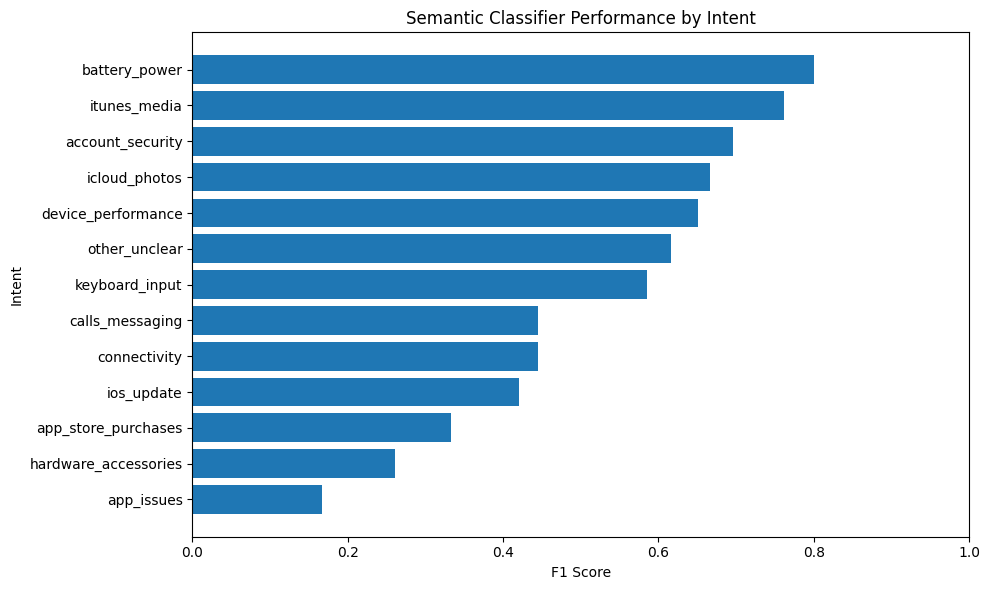

In [ ]:
import matplotlib.pyplot as plt

plot_data = per_class_results.sort_values("f1-score")

plt.figure(figsize=(10, 6))
plt.barh(plot_data.index, plot_data["f1-score"])
plt.xlabel("F1 Score")
plt.ylabel("Intent")
plt.title("Semantic Classifier Performance by Intent")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [121]:
# ============================================================
# TOP-5 FAILURE MODES WITH REAL EXAMPLES
# ============================================================

# Use the semantic classifier predictions already stored
failure_df = golden_set[
    golden_set["intent"] != golden_set["predicted_intent_semantic"]
].copy()

# Count the most common true -> predicted errors
top_failures = (
    failure_df
    .groupby(["intent", "predicted_intent_semantic"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(5)
)

print("TOP 5 FAILURE MODES")
display(top_failures)

print("\nREAL EXAMPLES")

for _, row in top_failures.iterrows():

    true_intent = row["intent"]
    predicted_intent = row["predicted_intent_semantic"]

    examples = failure_df[
        (failure_df["intent"] == true_intent) &
        (failure_df["predicted_intent_semantic"] == predicted_intent)
    ].head(2)

    print("\n" + "=" * 80)
    print(
        f"TRUE: {true_intent}  ->  "
        f"PREDICTED: {predicted_intent}  "
        f"(count = {row['count']})"
    )
    print("=" * 80)

    for _, ex in examples.iterrows():
        print("\nCustomer message:")
        print(ex["customer_text"])

TOP 5 FAILURE MODES


,intent,predicted_intent_semantic,count
39,keyboard_input,other_unclear,11
20,device_performance,ios_update,6
9,app_store_purchases,other_unclear,4
27,hardware_accessories,other_unclear,4
46,other_unclear,ios_update,4



REAL EXAMPLES

TRUE: keyboard_input  ->  PREDICTED: other_unclear  (count = 11)

Customer message:
Clearly need to stop using a first-person pronoun until @115858 can get their shit together.

Customer message:
This capital i shit is annoying af. @AppleSupport when y’all fixing this?

TRUE: device_performance  ->  PREDICTED: ios_update  (count = 6)

Customer message:
@AppleSupport please release an update to speed up iPhone 5S running iOS 11. Laggy OS on 5S is irritating.

Customer message:
@AppleSupport where can i find iOS10 for my iPhone 6?  iPhone is completely useless with iOS 11. Consistently hangs, freezes, and crashes and is making my blood boil.

TRUE: app_store_purchases  ->  PREDICTED: other_unclear  (count = 4)

Customer message:
@115858 why is it I can’t delete my credit card off my phone? I have a big issue with this

Customer message:
@AppleSupport Kindly fix it.

TRUE: hardware_accessories  ->  PREDICTED: other_unclear  (count = 4)

Customer message:
@AppleSupport I️ s

### Failure Hypotheses and Improvements

The five most frequent classification errors on the Golden Evaluation Set were:

### 1. `keyboard_input → other_unclear`
**Count:** 11

These errors occur when keyboard/autocorrect complaints are very short, noisy, or contain unusual characters such as the iOS “I” bug. Messages such as repeated “I” characters or short complaints can lose the semantic signal needed by the classifier.

**Hypothesis:** The embedding model does not always distinguish short keyboard-specific messages from generic or unclear support requests.

**Potential improvement:** Add more keyboard-specific examples to the training data and use targeted keyword/entity features for known issues such as the iOS “I” character problem.

### 2. `device_performance → ios_update`
**Count:** 6

These cases typically mention both an iOS update and a resulting performance problem, such as freezing, crashing, or lagging.

**Hypothesis:** The classifier overweights explicit references to “iOS”, “update”, or version numbers even when the customer's actual problem is device performance.

**Potential improvement:** Introduce clearer annotation rules for cases where an update is the cause/context but performance is the primary complaint.

### 3. `app_store_purchases → other_unclear`
**Count:** 4

Some App Store or purchase-related messages are short or provide insufficient context, making them difficult to distinguish from unclear requests.

**Hypothesis:** Sparse purchase-related messages do not contain enough semantic information for reliable classification.

**Potential improvement:** Add more representative App Store, purchase, download, and payment examples to the labelled training set.

### 4. `hardware_accessories → other_unclear`
**Count:** 4

Hardware and accessory complaints can be very short or rely on information contained in an image or omitted context.

**Hypothesis:** Text-only embeddings cannot reliably infer hardware/accessory intent when the message contains little descriptive information.

**Potential improvement:** Use a dedicated hardware/accessory class with more labelled examples and escalate image-dependent cases by default.

### 5. `other_unclear → ios_update`
**Count:** 4

Some messages that are too vague to assign confidently to a specific intent contain explicit iOS version numbers or update-related terms.

**Hypothesis:** The classifier interprets the visible update/version terminology as stronger evidence for `ios_update` than the lack of sufficient context warrants.

**Potential improvement:** Add an uncertainty threshold and route low-information messages to `other_unclear`/ESCALATE instead of relying only on the highest predicted class.

### Overall observation

The failure analysis shows that many errors occur at the boundary between closely related intents or when messages are extremely short and noisy. This supports using the classifier together with retrieval and a conservative escalation policy rather than treating the predicted intent as sufficient for fully autonomous handling.

In [ ]:
one_week_plan = pd.DataFrame({
    "Priority": [1, 2, 3, 4, 5],
    "Improvement": [
        "Refine the intent taxonomy",
        "Add more high-quality human-labelled examples",
        "Improve retrieval with intent-aware filtering",
        "Use a stronger generation model when API quota is available",
        "Add human evaluation for generated responses"
    ],
    "Why": [
        "Current errors show overlap between device_performance and ios_update, and many vague messages.",
        "Minority intents such as app_issues and hardware_accessories have low F1.",
        "Relevant historical replies can sometimes be retrieved even when classification fails.",
        "FLAN-T5-small produced weak responses; Gemini produced better grounded responses in successful tests.",
        "LLM-as-judge results should be compared against human ratings to measure judge reliability."
    ]
})

display(one_week_plan)

,Priority,Improvement,Why
0,1,Refine the intent taxonomy,"Current errors show overlap between device_performance and ios_update, and many vague messages."
1,2,Add more high-quality human-labelled examples,Minority intents such as app_issues and hardware_accessories have low F1.
2,3,Improve retrieval with intent-aware filtering,Relevant historical replies can sometimes be retrieved even when classification fails.
3,4,Use a stronger generation model when API quota is available,FLAN-T5-small produced weak responses; Gemini produced better grounded responses in successful tests.
4,5,Add human evaluation for generated responses,LLM-as-judge results should be compared against human ratings to measure judge reliability.


## One-Week Improvement Plan

### Day 1 — Expand and rebalance the evaluation set
Review the Golden Set distribution and add more examples for intents with weak representation, particularly `app_issues`, `connectivity`, `app_store_purchases`, and `hardware_accessories`.

### Day 2 — Improve intent definitions
Review the most common confusion pairs, especially:
- `keyboard_input` ↔ `other_unclear`
- `device_performance` ↔ `ios_update`
- `app_store_purchases` ↔ `other_unclear`

Refine annotation guidelines and add boundary examples for these cases.

### Day 3 — Improve classification
Experiment with class-specific thresholds, better embedding models, and alternative classifiers. Evaluate changes only on a held-out evaluation set.

### Day 4 — Improve retrieval
Increase the retrieval pool and test different similarity strategies. Add metadata such as intent labels so retrieved historical replies are more likely to belong to the predicted intent.

### Day 5 — Improve response generation
Evaluate different prompting strategies for grounding, including explicit instructions to use only information supported by retrieved historical responses and to escalate when the evidence is insufficient.

### Day 6 — Improve AUTO/ESCALATE decisions
Use a separate development set to tune escalation rules. Investigate whether classifier confidence, intent type, retrieval similarity, and ambiguity indicators can improve the routing decision.

### Day 7 — End-to-end evaluation
Run the complete pipeline on a fresh evaluation set and compare:
- intent classification
- AUTO/ESCALATE routing
- retrieval quality
- generated-response quality
- LLM-judge scores
- human evaluation
- judge–human agreement

Document the largest remaining failure modes and prioritize them for the next iteration.

## 16. Decision Log

| Decision | Why we made it | Trade-off / consequence |
|---|---|---|
| **1. Selected AppleSupport as the target brand** | It provides a large number of customer-support interactions in the dataset, making it suitable for evaluation. | The resulting taxonomy and policies are specific to AppleSupport rather than general customer support. |
| **2. Used inbound customer tweets and their linked AppleSupport replies** | This preserves the original customer → brand-response relationship needed for grounded response generation. | Some conversations may still lack sufficient context because the dataset is based on individual linked tweets. |
| **3. Defined 13 support intents** | A small, interpretable taxonomy makes classification and downstream handling easier to evaluate. | Some real customer messages naturally span multiple intents and do not fit perfectly into one class. |
| **4. Added `other_unclear` as an explicit intent** | Short, vague, image-dependent, or unsupported messages cannot always be assigned reliably to a specific support category. | This class became relatively large and can hide some difficult edge cases. |
| **5. Created a 200-example Golden Evaluation Set** | A manually labelled evaluation set provides a consistent basis for measuring classification performance. | The set is relatively small and should not be treated as fully representative of all AppleSupport traffic. |
| **6. Kept the Golden Set separate from training data** | Prevents direct leakage between training and evaluation and gives a cleaner estimate of generalization. | Less labelled data is available for model training. |
| **7. Used a majority-class baseline** | Provides a simple reference point for determining whether learned models provide meaningful improvement. | It is intentionally weak and does not use message content. |
| **8. Compared TF-IDF + Logistic Regression with sentence embeddings + Logistic Regression** | This tests both a traditional lexical approach and a semantic representation approach. | More sophisticated modelling does not automatically guarantee better performance on every intent. |
| **9. Chose sentence embeddings as the main classifier** | It achieved higher overall accuracy than the TF-IDF baseline on the Golden Set. | Several minority intents still had weak F1 scores, so the classifier is not sufficient for autonomous handling by itself. |
| **10. Kept zero-shot classification as a failed experiment** | The experiment tested whether a pretrained semantic approach could work without task-specific training. | Its performance was lower than the trained classifiers, so it was not selected as the main approach. |
| **11. Used historical AppleSupport responses for retrieval** | Historical responses provide brand-specific grounding and help maintain an appropriate support style. | Retrieved responses can be incomplete or imperfectly matched to the new customer message. |
| **12. Did not rely on classifier confidence alone for handling decisions** | Confidence scores were similar for AUTO and ESCALATE examples, so confidence alone was not a reliable safety signal. | The final handling policy is more conservative and escalates many cases. |
| **13. Used a conservative AUTO-HANDLE policy** | Only selected intents with relatively clear and repeatable support patterns were considered for automatic handling. | This reduces automation coverage in exchange for more cautious handling. |
| **14. Used an LLM judge for generated-response evaluation** | Relevance, groundedness, helpfulness, tone, and unsupported claims are difficult to capture with simple exact-match metrics. | LLM-based evaluation can itself contain biases and therefore should be complemented with human evaluation. |
| **15. Included human evaluation and agreement analysis** | Comparing human ratings with LLM-judge scores provides an initial check on whether automated evaluation is directionally useful. | Only 10 overlapping examples were available, so the agreement result is preliminary. |

In [ ]:
decision_log = pd.DataFrame({
    "Decision": [
        "Choose AppleSupport as the target brand",
        "Use customer-to-brand reply pairs",
        "Use a 13-intent taxonomy",
        "Keep other_unclear as an explicit intent",
        "Use a 20,000-example development sample",
        "Keep the Golden Set separate from training",
        "Use human labels as Golden Set ground truth",
        "Use majority class as the trivial baseline",
        "Use TF-IDF + Logistic Regression as the simple baseline",
        "Use sentence embeddings + Logistic Regression as the semantic model",
        "Use historical AppleSupport replies for response grounding",
        "Use a conservative intent-based AUTO/ESCALATE policy"
    ],
    "Rationale": [
        "AppleSupport had a large number of clean customer-response pairs, providing enough data for experimentation.",
        "Pairing each customer message with its actual historical brand response preserves the support interaction structure.",
        "The taxonomy captures recurring support themes while keeping the classification problem manageable.",
        "Some messages are vague, unsupported, or insufficiently informative for a specific intent, so forcing them into another category would introduce label noise.",
        "The full dataset is very large; a fixed sample makes experimentation computationally practical while retaining substantial training data.",
        "Evaluation data must remain unseen during training to provide a meaningful estimate of generalization.",
        "Human annotation provides the reference labels instead of treating heuristic or model-generated labels as ground truth.",
        "A majority predictor establishes the minimum useful reference point for classification performance.",
        "TF-IDF with Logistic Regression provides a strong, interpretable classical NLP baseline.",
        "Sentence embeddings capture semantic similarity beyond exact word overlap and provide a complementary model to the lexical baseline.",
        "Historical responses provide evidence for how the brand actually responded rather than relying only on invented answers.",
        "Low-risk recurring intents are allowed for automatic handling, while other intents are escalated to reduce unsupported automated responses."
    ]
})

display(decision_log)

,Decision,Rationale
0,Choose AppleSupport as the target brand,"AppleSupport had a large number of clean customer-response pairs, providing enough data for experimentation."
1,Use customer-to-brand reply pairs,Pairing each customer message with its actual historical brand response preserves the support interaction structure.
2,Use a 13-intent taxonomy,The taxonomy captures recurring support themes while keeping the classification problem manageable.
3,Keep other_unclear as an explicit intent,"Some messages are vague, unsupported, or insufficiently informative for a specific intent, so forcing them into another category would introduce label noise."
4,"Use a 20,000-example development sample",The full dataset is very large; a fixed sample makes experimentation computationally practical while retaining substantial training data.
5,Keep the Golden Set separate from training,Evaluation data must remain unseen during training to provide a meaningful estimate of generalization.
6,Use human labels as Golden Set ground truth,Human annotation provides the reference labels instead of treating heuristic or model-generated labels as ground truth.
7,Use majority class as the trivial baseline,A majority predictor establishes the minimum useful reference point for classification performance.
8,Use TF-IDF + Logistic Regression as the simple baseline,"TF-IDF with Logistic Regression provides a strong, interpretable classical NLP baseline."
9,Use sentence embeddings + Logistic Regression as the semantic model,Sentence embeddings capture semantic similarity beyond exact word overlap and provide a complementary model to the lexical baseline.


## 17. Final Results Summary

| Component | Result |
|---|---|
| **Target brand** | AppleSupport |
| **Development data** | 20,000 AppleSupport customer–response pairs |
| **Intent taxonomy** | 13 intents |
| **Golden Evaluation Set** | 200 manually labelled examples, kept separate from training |
| **Majority baseline** | 22.5% accuracy |
| **TF-IDF + Logistic Regression** | 52.5% accuracy, 0.502 macro-F1 |
| **Sentence Embeddings + Logistic Regression** | **57.0% accuracy, 0.527 macro-F1** |
| **Zero-shot classifier** | 39.0% accuracy |
| **Retrieval** | Top-3 historical AppleSupport responses using semantic similarity |
| **Auto-handle policy** | `keyboard_input`, `itunes_media`, `connectivity` |
| **Generation** | 17 of 30 planned examples successfully generated before Gemini API quota was exhausted |
| **LLM-judge evaluation** | 17/17 generated responses evaluated |
| **LLM-judge overall score** | 4.45 / 5 |
| **Human evaluation** | 10 examples, 4.46 / 5 overall mean |
| **Human–LLM agreement** | Spearman ρ = 0.465, p = 0.175, n = 10 |

### Key Takeaways

- Sentence embeddings improved classification accuracy over both the majority baseline and TF-IDF baseline.
- Performance remains uneven across intents, so overall accuracy alone is not sufficient to assess the system.
- Historical-response retrieval provides brand-specific grounding but does not guarantee a complete or correct response.
- The conservative handling policy favors escalation when the intent is ambiguous or outside the predefined auto-handle set.
- Generated responses received strong groundedness and tone scores from the LLM judge, while helpfulness remained the main area for improvement.
- Human and LLM-judge ratings showed a moderate positive association, but the small sample means this result should be treated as preliminary.

## 18. Reproducibility and Setup

The project was developed in Google Colab and can be reproduced using the notebook and the provided dataset.

### Setup

1. Open the notebook in Google Colab.
2. Install the required Python packages listed in the notebook.
3. Load the `Customer Support on Twitter` dataset.
4. Set the target brand to `AppleSupport`.
5. Run the notebook cells sequentially to reproduce:
   - Dataset filtering and customer-response pairing
   - Exploratory analysis
   - Intent taxonomy and Golden Evaluation Set
   - Classification baselines
   - Sentence-embedding classifier
   - Retrieval pipeline
   - Response generation
   - LLM-judge evaluation
   - Failure analysis and final metrics

### External API

Response generation and LLM-based evaluation use the Gemini API.

The API key is expected through the `GEMINI_API_KEY` environment/Colab Secret and is not stored in the notebook or repository.

### Saved Evaluation Artifacts

The notebook saves intermediate evaluation progress so that long-running API experiments can be resumed without repeating completed requests.

The main artifacts include:

- `generation_eval_progress.csv`
- `human_eval_progress.csv`

No API keys or private credentials are included in the repository.

## 19. Final Submission Checklist

The project covers the required evaluation components:

- [x] Problem framing: definition of "good" and explicit non-goals
- [x] Brand selection and dataset construction
- [x] Intent taxonomy
- [x] 200-example manually labelled Golden Evaluation Set
- [x] Sampling and labelling considerations
- [x] Majority-class baseline
- [x] TF-IDF + Logistic Regression baseline
- [x] Sentence-embedding classifier
- [x] Automated classification metrics
- [x] Confusion/failure analysis
- [x] Retrieval of historical brand responses
- [x] Grounded response generation
- [x] LLM-as-judge evaluation
- [x] Human evaluation
- [x] Human–LLM judge agreement analysis
- [x] Top-5 failure modes with real examples
- [x] One misleading headline metric and explanation
- [x] One-week improvement plan
- [x] 15-entry decision log
- [x] Reproducibility and setup instructions
- [x] API key kept outside the repository
- [x] Intermediate evaluation artifacts saved for resumability

### Important limitation

The response-generation experiment successfully generated responses for 17 of the 30 planned examples before the Gemini API quota was exhausted. Therefore, generation-quality conclusions are based on those 17 evaluated responses rather than all 30 planned examples.